In [43]:
# Add imports 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from sspspace.sspspace.encoders import RandomSSPSpace

import nengo
from nengo.network import Network
from nengo import Node, Connection

from contrastive import CPCA


# Import the basal Ganglia model 
%load_ext autoreload
%autoreload 2
from bg_model import BasalGanglia
%load_ext autoreload
%autoreload 2
from utility import Utility, ActionIterator
%load_ext autoreload
%autoreload 2
from pca_analysis import Trial, Session, PCAAnalysis, cPCAAnalysis

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


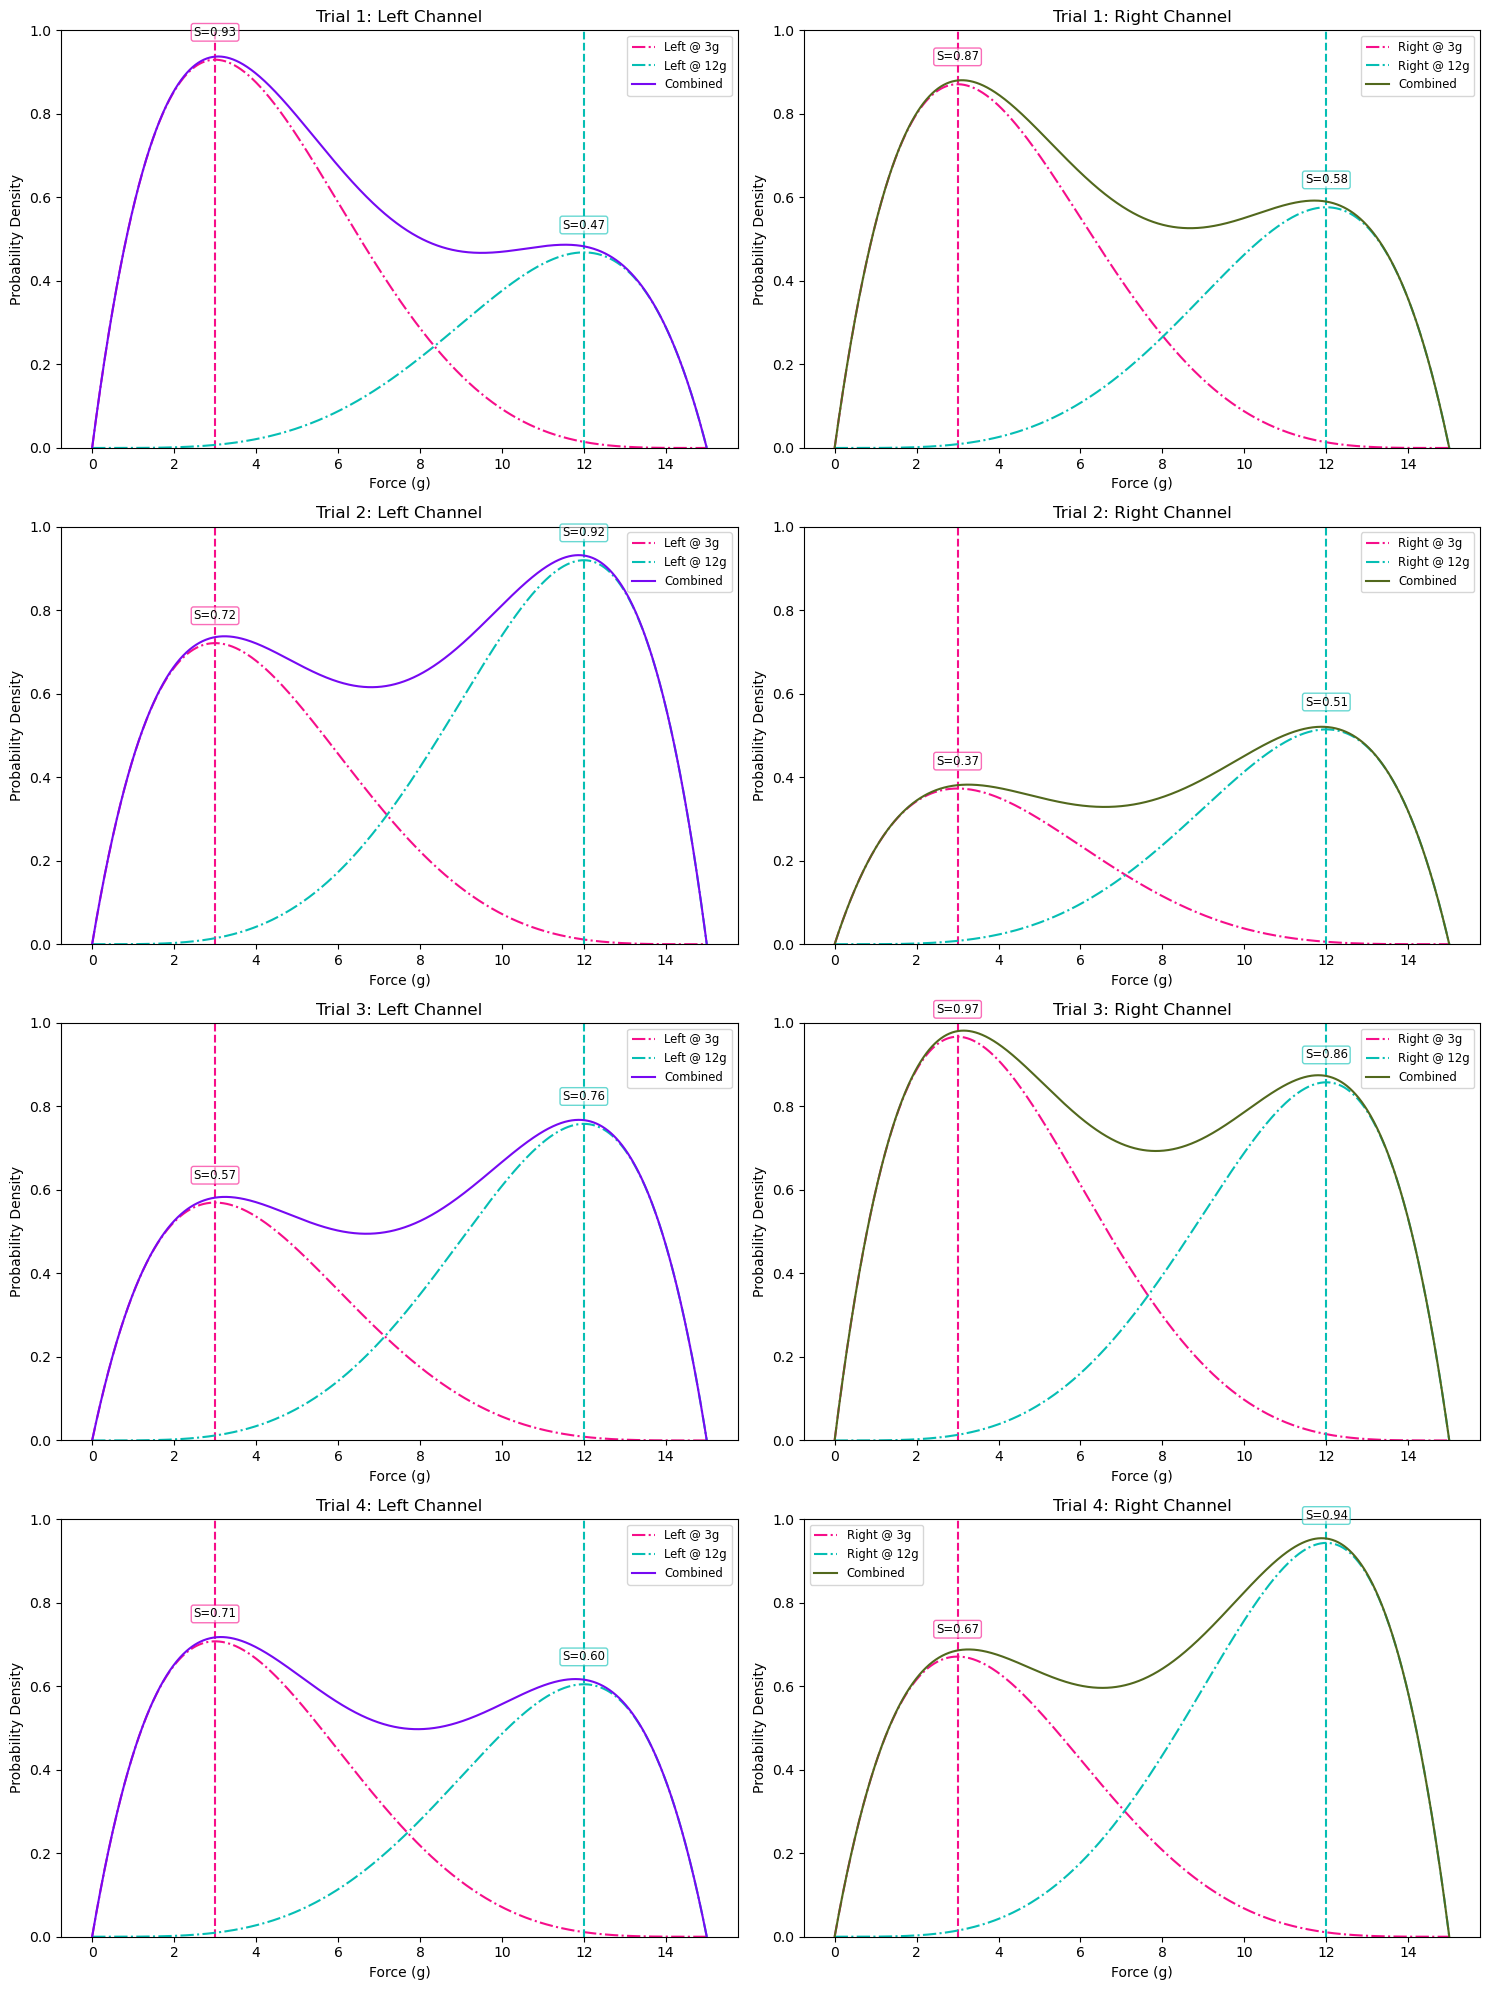

In [44]:
%matplotlib inline
# 1) Initialize and prepare encoders + distributions
dnf_params_park = {
            'h'       : -3.009416816439706,
            'global_inh'      : 8.641108231311897,
            'tau'             : 0.04706404390267922,
            'exc'             : 9.421285790349613,
            'inh'             : 1.4841093480380807,
            'exc_w'           : 8.534993467227224,
            'inh_w'           : 4.748154014869723,
            'dt'              : 0.001, 
            'c_noise'         : 1.0,
            'shape'           : [(2, 1500)], 
            'beta'            : 4,
    }

trial = Trial(dnf_params=dnf_params_park, n_actions=2, domain=np.linspace(0, 15, 1500))
trial._create_domain_phis(length_scale=0.5, rng_seed=0, domain_dim=1)
trial._create_dnf_encoders()
trial._create_bimodal_distributions()

# 2) Create bundles and get the four salience vectors used
bundles, saliences_list = trial.create_bundles()

# 3) Plot the 4×2 grid (uses saliences_list so titles + annotations match)
fig, axes, _ = trial.plot_trial_distributions(saliences_list=saliences_list, save_fig=True, plt_name='example')
plt.show()


In [45]:
# Run the trial
data = trial.run_trial() # Each trial takes an average of ~1m40s - 2mins to run

running Bg model now


HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

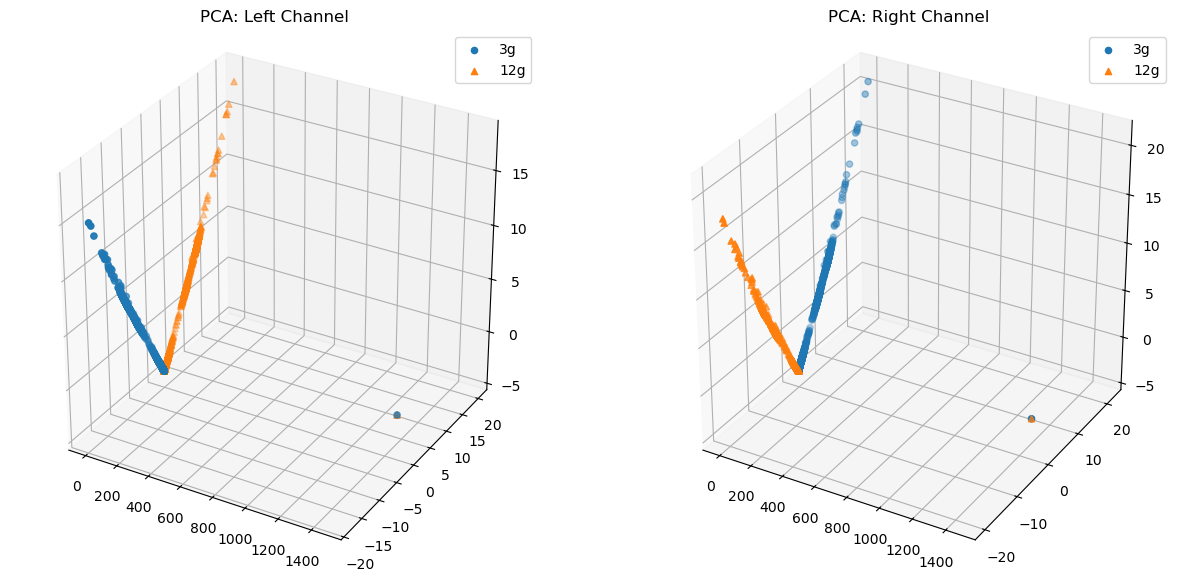

In [56]:
t1 = data[0]['d1_neuron'][:, :1500] # a1
t2 = data[1]['d1_neuron'][:, :1500] # a1
t3 = data[2]['d1_neuron'][:, -1500:] # a2
t4 = data[3]['d1_neuron'][:, -1500:] # a2

a1_target = np.vstack([t1, t2])
a2_target = np.vstack([t3, t4])

a1_labels = (t1.shape[1])*[3] + (t1.shape[1])*[12]
# a1_labels = np.concatenate(((np.ones(last_time) * 3), np.ones(last_time) * 12))
a2_labels = (t3.shape[1])*[3] + (t4.shape[1])*[12]

# ============= PCA ====================
pca_model = PCAAnalysis(n_components=3)
# left, right, left_labels, right_labels = pca_model.data_format(data_type='npz', foreground_paths=foreground_npz, key = 'd1_neuron', discard=350, select=1500)
# Perform PCA analysis 
# Left channel 
left_pca = pca_model.pca(a1_target)
# Right channel 
right_pca = pca_model.pca(a2_target)
# in Jupyter
# 1) once per notebook:
# %pip install ipympl
# %matplotlib widget

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=(15, 8))

def plot_panel(ax, X, labels, title):
    m3  = labels == 3
    m12 = labels == 12
    ax.scatter(X[m3,0],  X[m3,1],  X[m3,2],  label='3g',  marker='o')
    ax.scatter(X[m12,0], X[m12,1], X[m12,2], label='12g', marker='^')
    ax.set_title(title)
    ax.legend()
    ax.set_box_aspect((1,1,1))  # nicer proportions

X1 = pca_model.to_real(left_pca)
X2 = pca_model.to_real(right_pca)   # (use right here; your snippet repeated left)
labels1 = np.asarray(a1_labels)
labels2 = np.asarray(a2_labels)

plot_panel(axes[0], X1, labels1, 'PCA: Left Channel')
plot_panel(axes[1], X2, labels2, 'PCA: Right Channel')
# plt.savefig('./figures/pca/session_pca.png')
plt.show()


In [57]:
noise_data = trial.generate_background_data() # Runtime: avg 1m42s-2m

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

In [ ]:
t1 = noise_data[0]['d1_neuron'][:, :1500] # a1
t2 = noise_data[1]['d1_neuron'][:, :1500] # a1
t3 = noise_data[2]['d1_neuron'][:, -1500:] # a2
t4 = noise_data[3]['d1_neuron'][:, -1500:] # a2

a1_background = np.vstack([t1, t2])
a2_background = np.vstack([t3, t4])

# ========= CPCA ====================
cpca_model = cPCAAnalysis(n_components=3, standardize=True) # Running time: 1m 28 sec
# left_fg, right_fg, left_label_fg, right_label_fg = cpca_model.data_format(data_type='npz', foreground_paths=foreground_npz, key='d1_neuron', discard=350, select=1500)
# left_bg, right_bg, _, _ = cpca_model.data_format(data_type='npz', foreground_paths=background_npz,key = 'd1_neuron', discard=350, select=1500)

# # Left channel cPCA
left_cpca, alpha_left = cpca_model.cpca(foreground_data=a1_target, background_data=a1_background, labels=a1_labels, return_alpha=True)
# # Right channel cPCA
right_cpca, alpha_right = cpca_model.cpca(foreground_data=a2_target, background_data=a2_background, labels=a2_labels, return_alpha=True)



(2, 4)


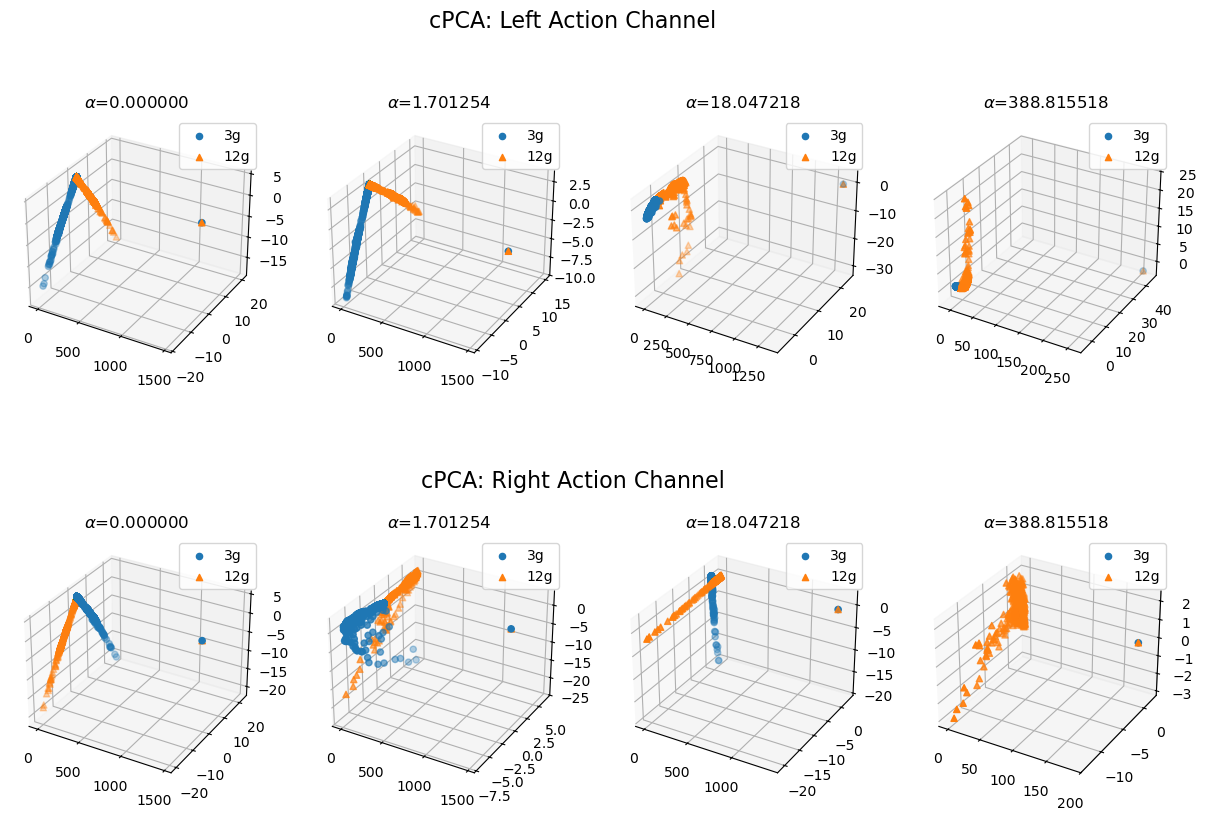

In [60]:
# LEFT GRAPHS
fig, axes = plt.subplots(2, len(alpha_left), subplot_kw={'projection': '3d'}, figsize=(15, 10))
print(axes.shape)
def projected_data_3dplots(axes, data, alphas, labels, titles):
    for i in range(len(alphas)):
        # convert the data into real data 
        X = cpca_model.to_real(data[i])
        graph_labels = np.asarray(labels)
        f3 = graph_labels == 3
        f12 = graph_labels == 12
        # plot 
        axes[i].scatter(X[f3, 0],  X[f3, 1],  X[f3, 2],  label='3g',  marker='o')
        axes[i].scatter(X[f12, 0], X[f12, 1], X[f12, 2], label='12g', marker='^')
        axes[i].set_title(r'$\alpha$=' + f'{alpha_left[i]:2f}')
        axes[i].legend()


projected_data_3dplots(axes[0, :], left_cpca, alpha_left, a1_labels, titles=[])
projected_data_3dplots(axes[1, :], right_cpca, alpha_right, a2_labels, titles=[])

fig.text(0.5, 0.92, "cPCA: Left Action Channel", ha='center', fontsize=16)
fig.text(0.5, 0.46, "cPCA: Right Action Channel", ha='center', fontsize=16)
plt.show()

running Bg model now


HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

...

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

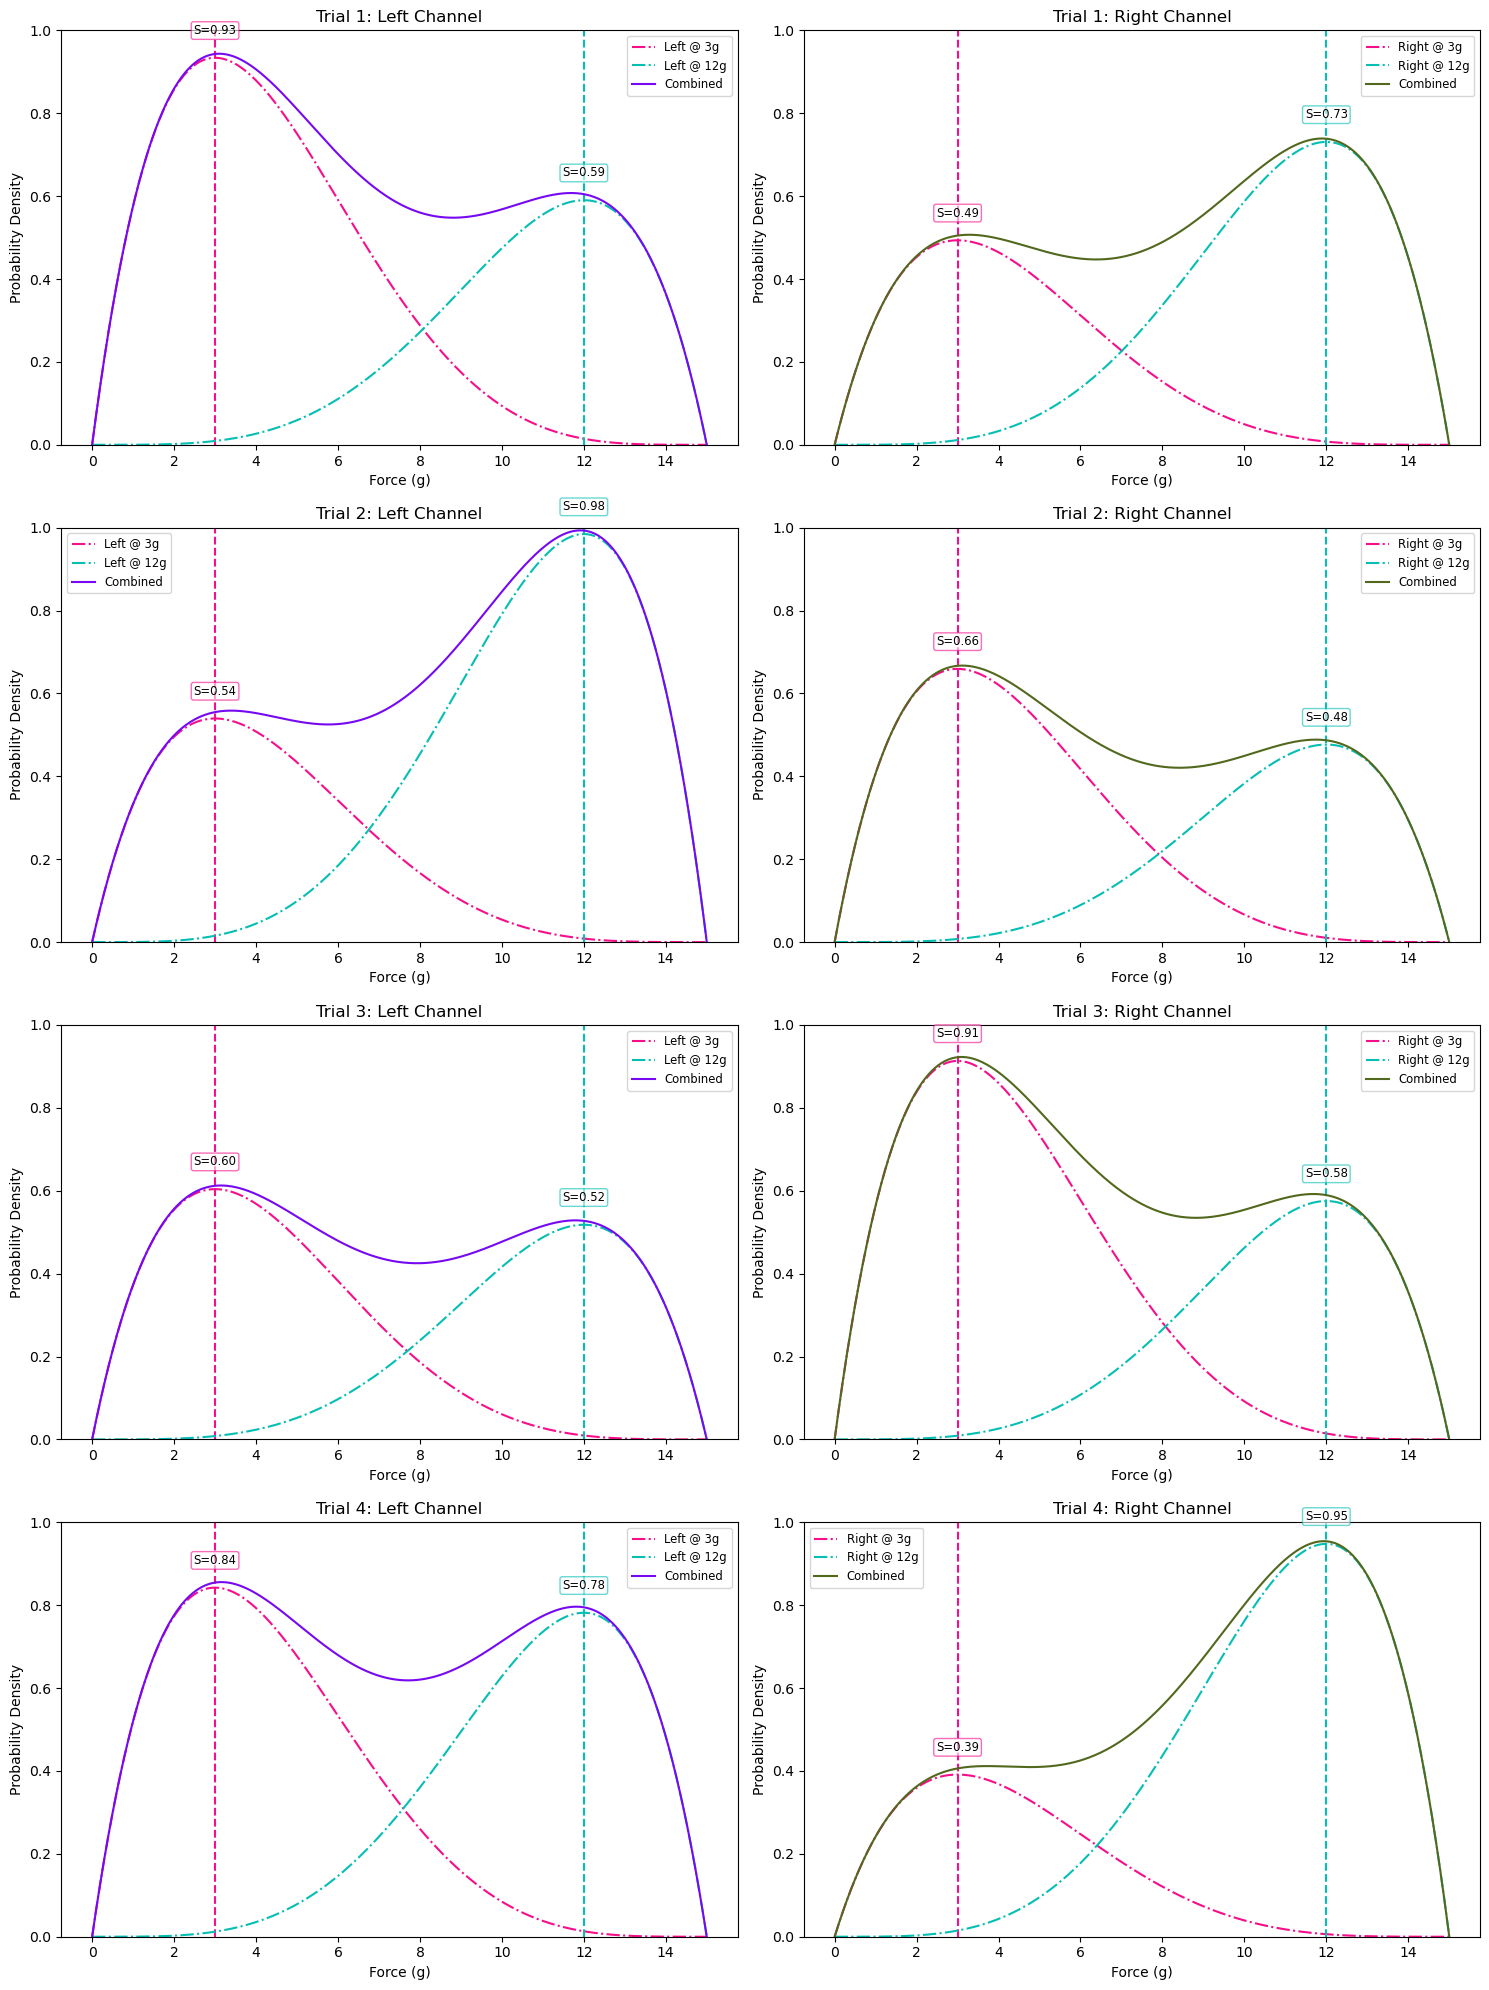

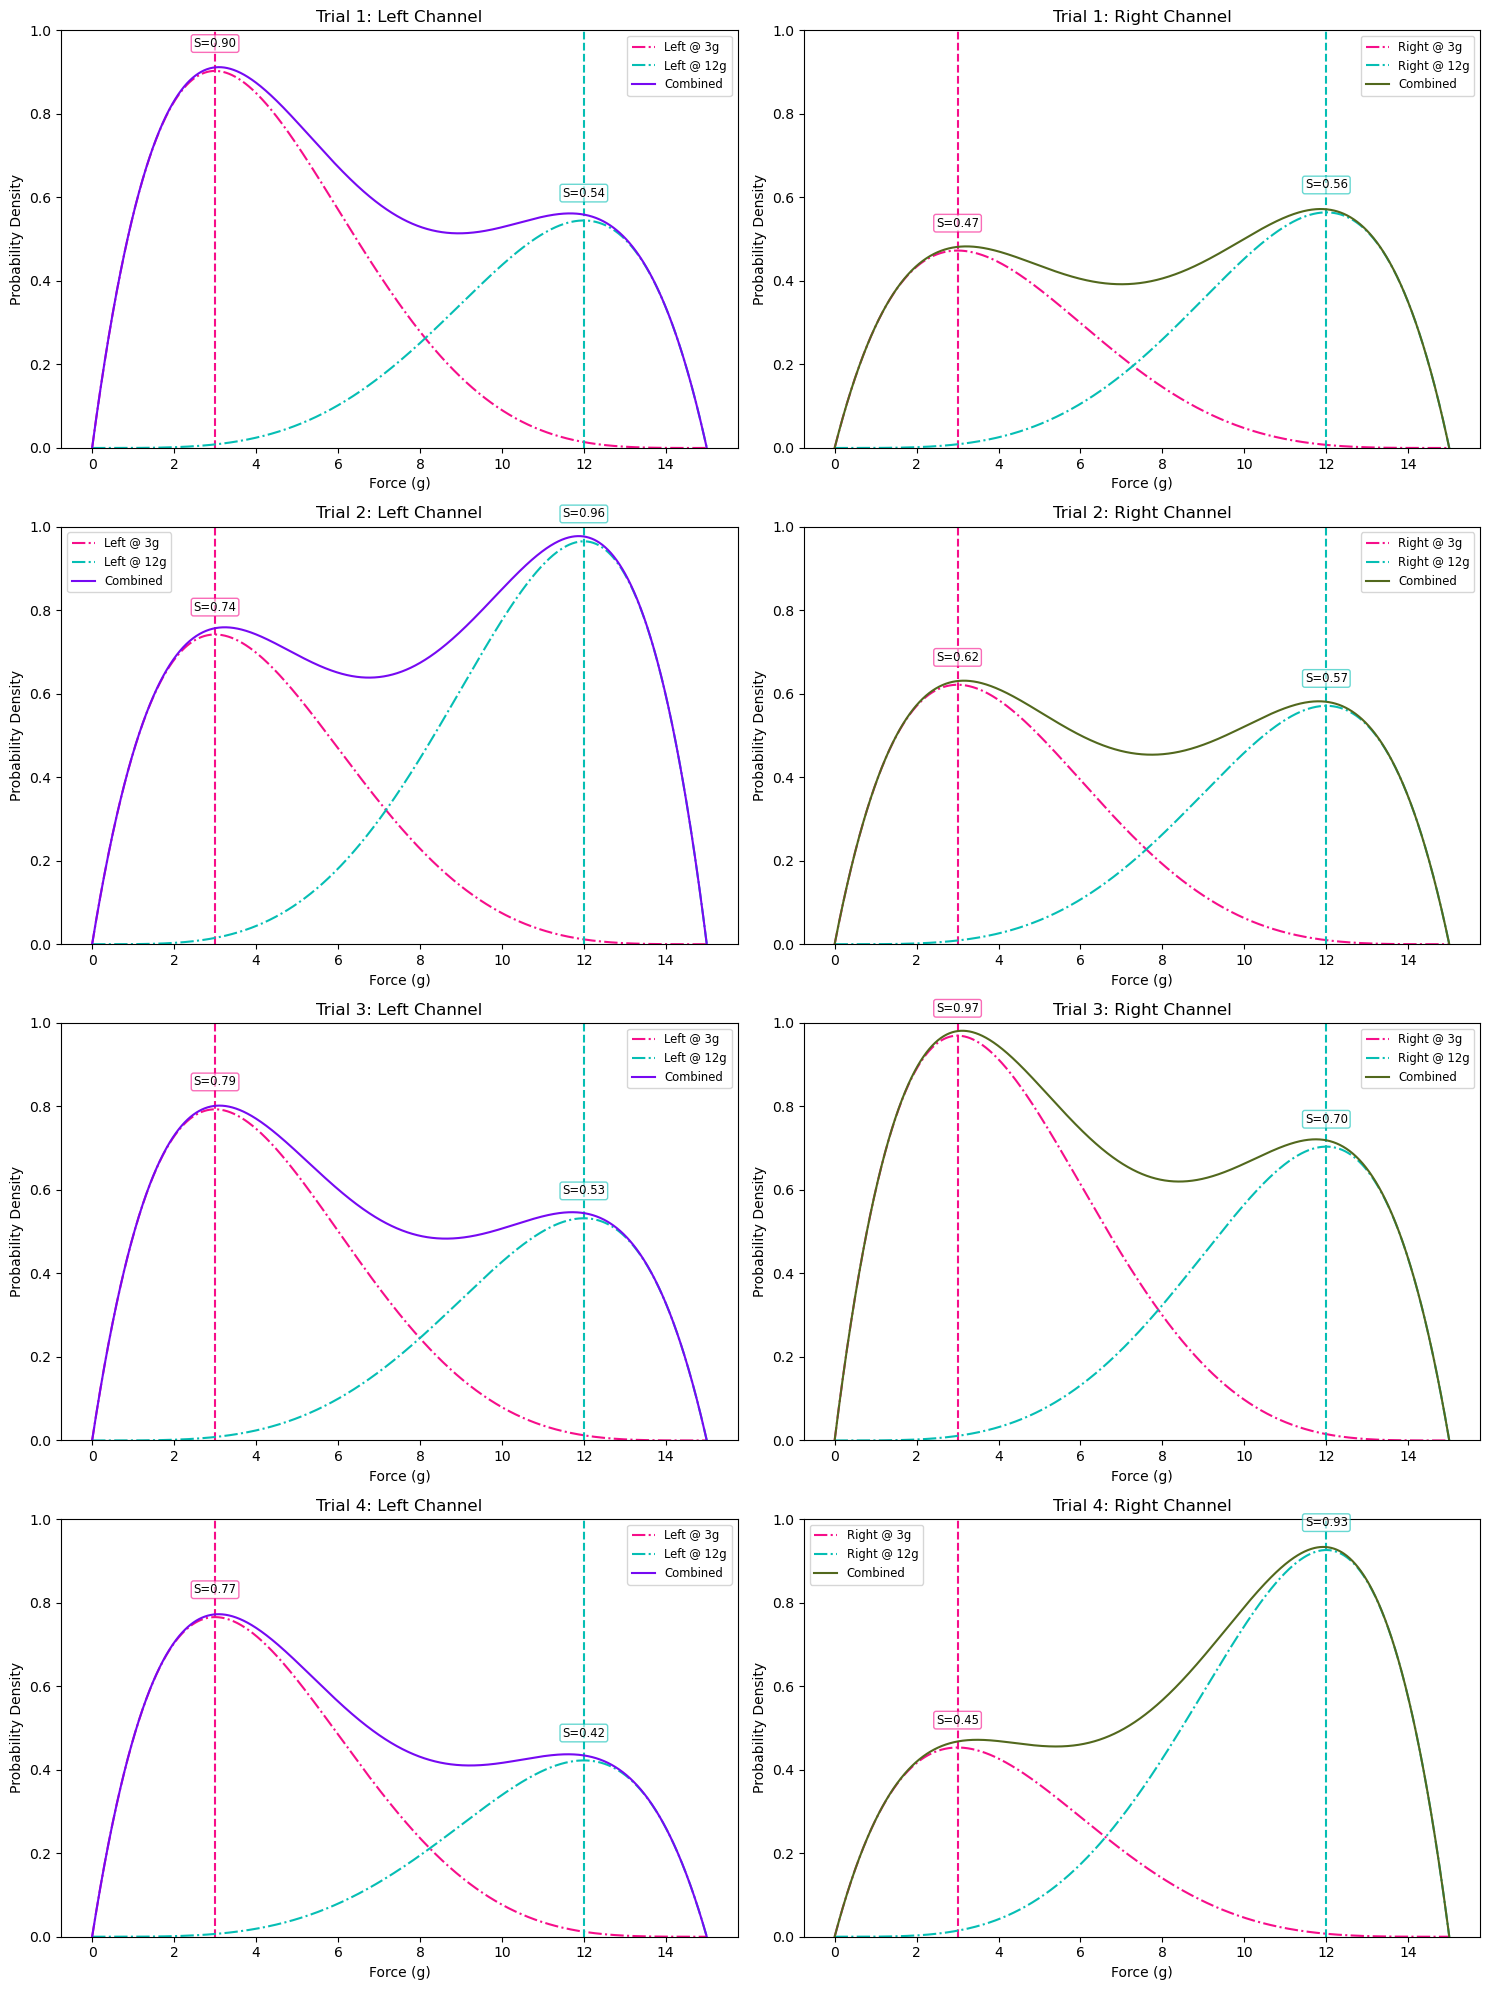

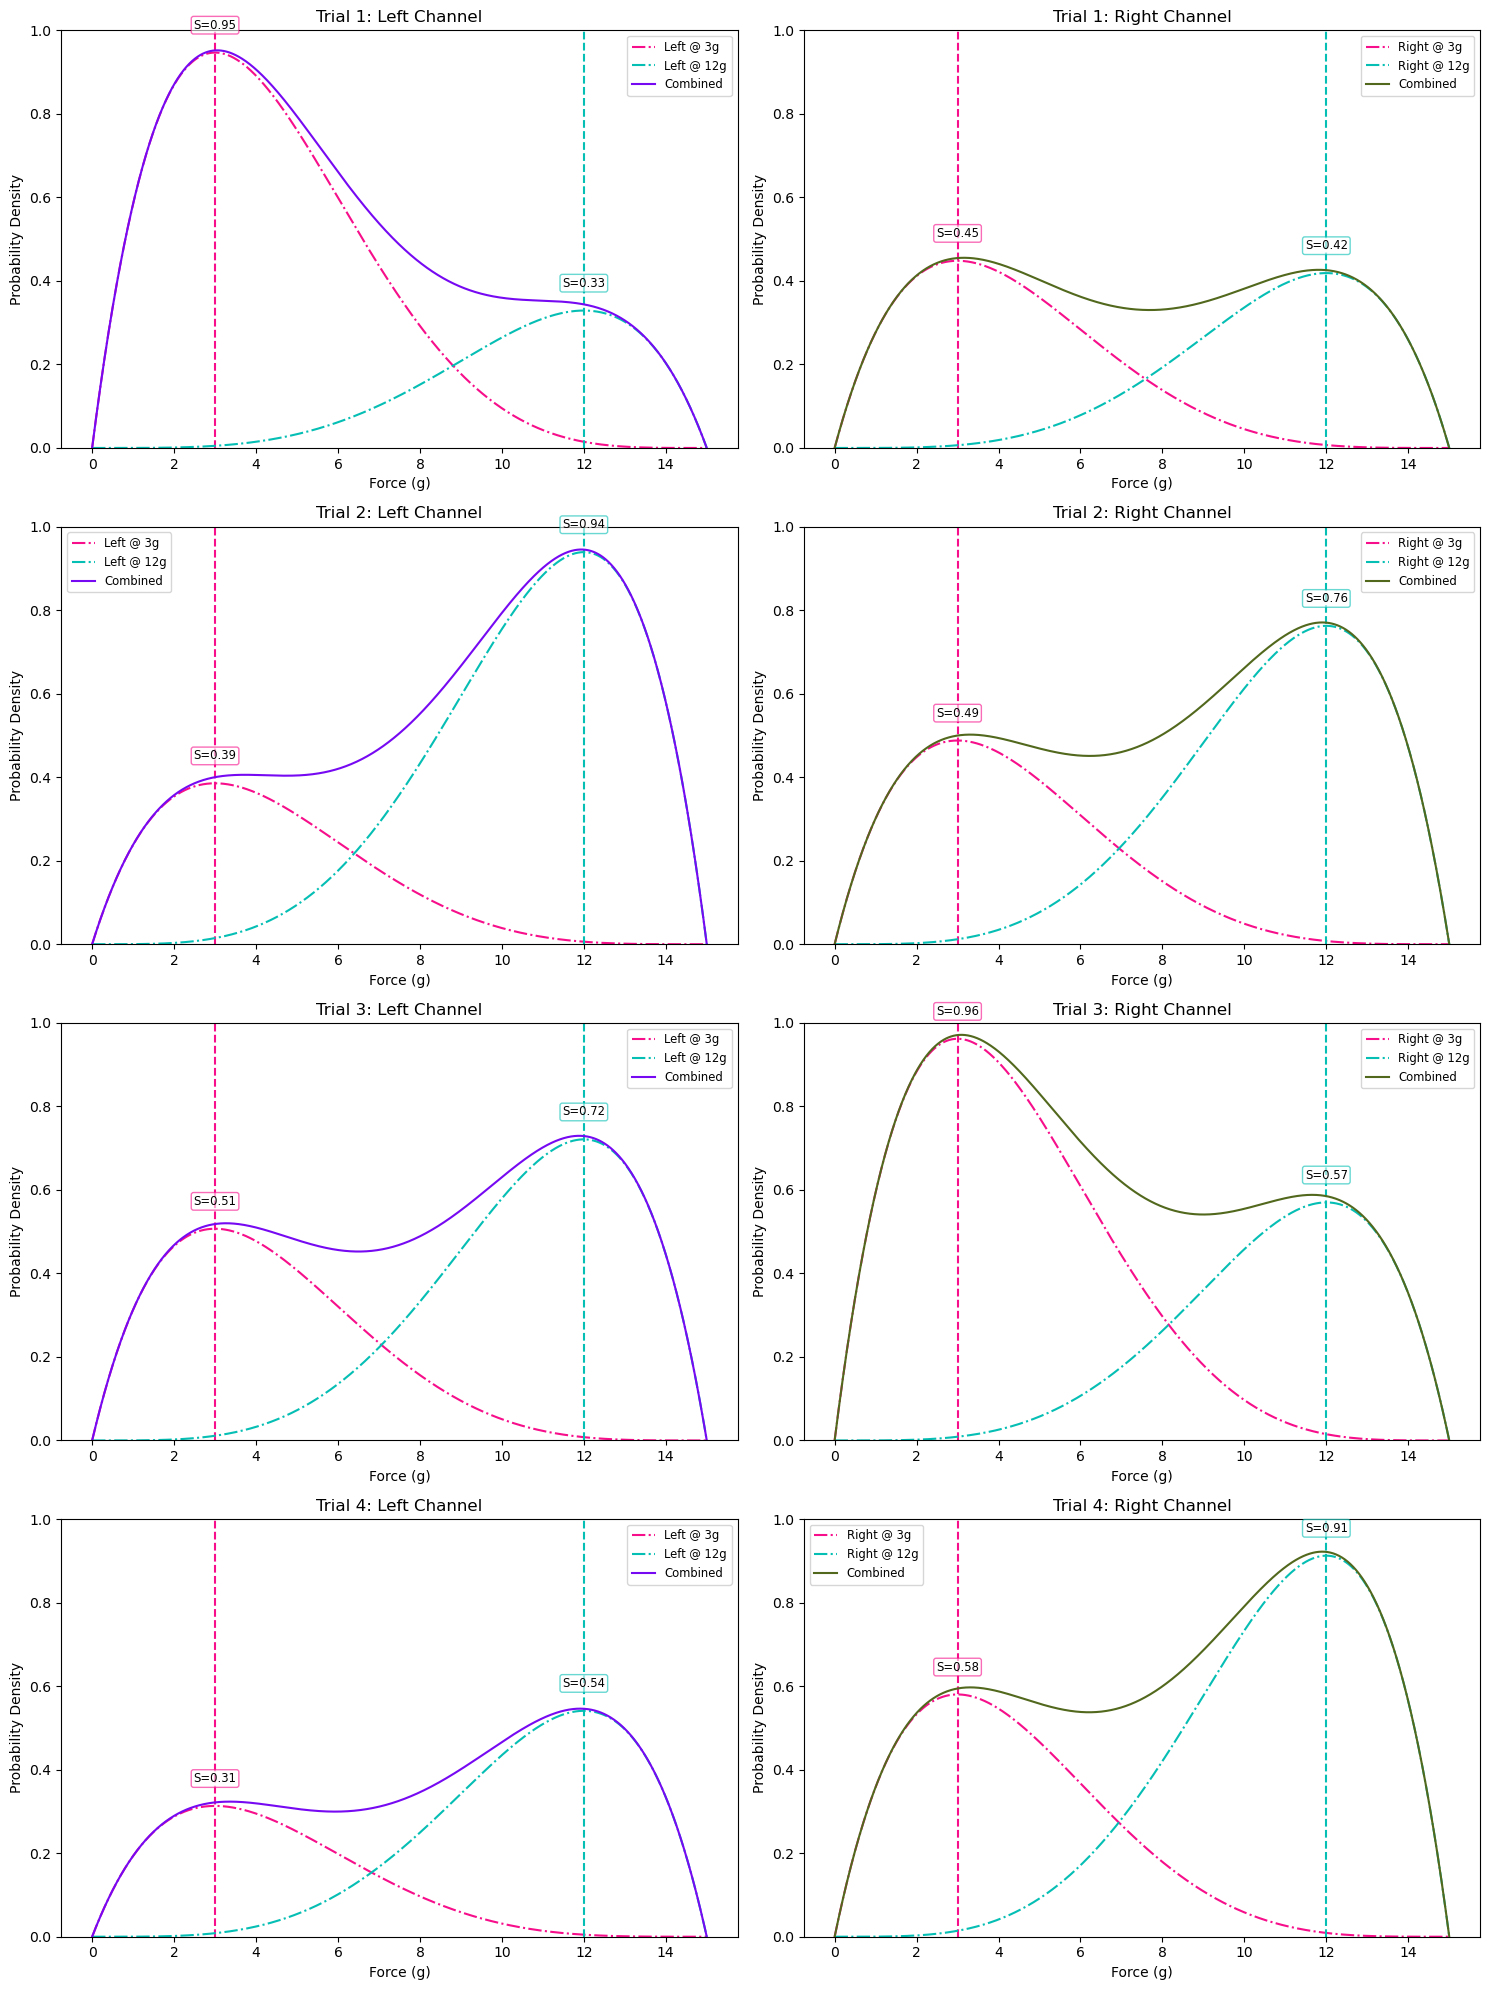

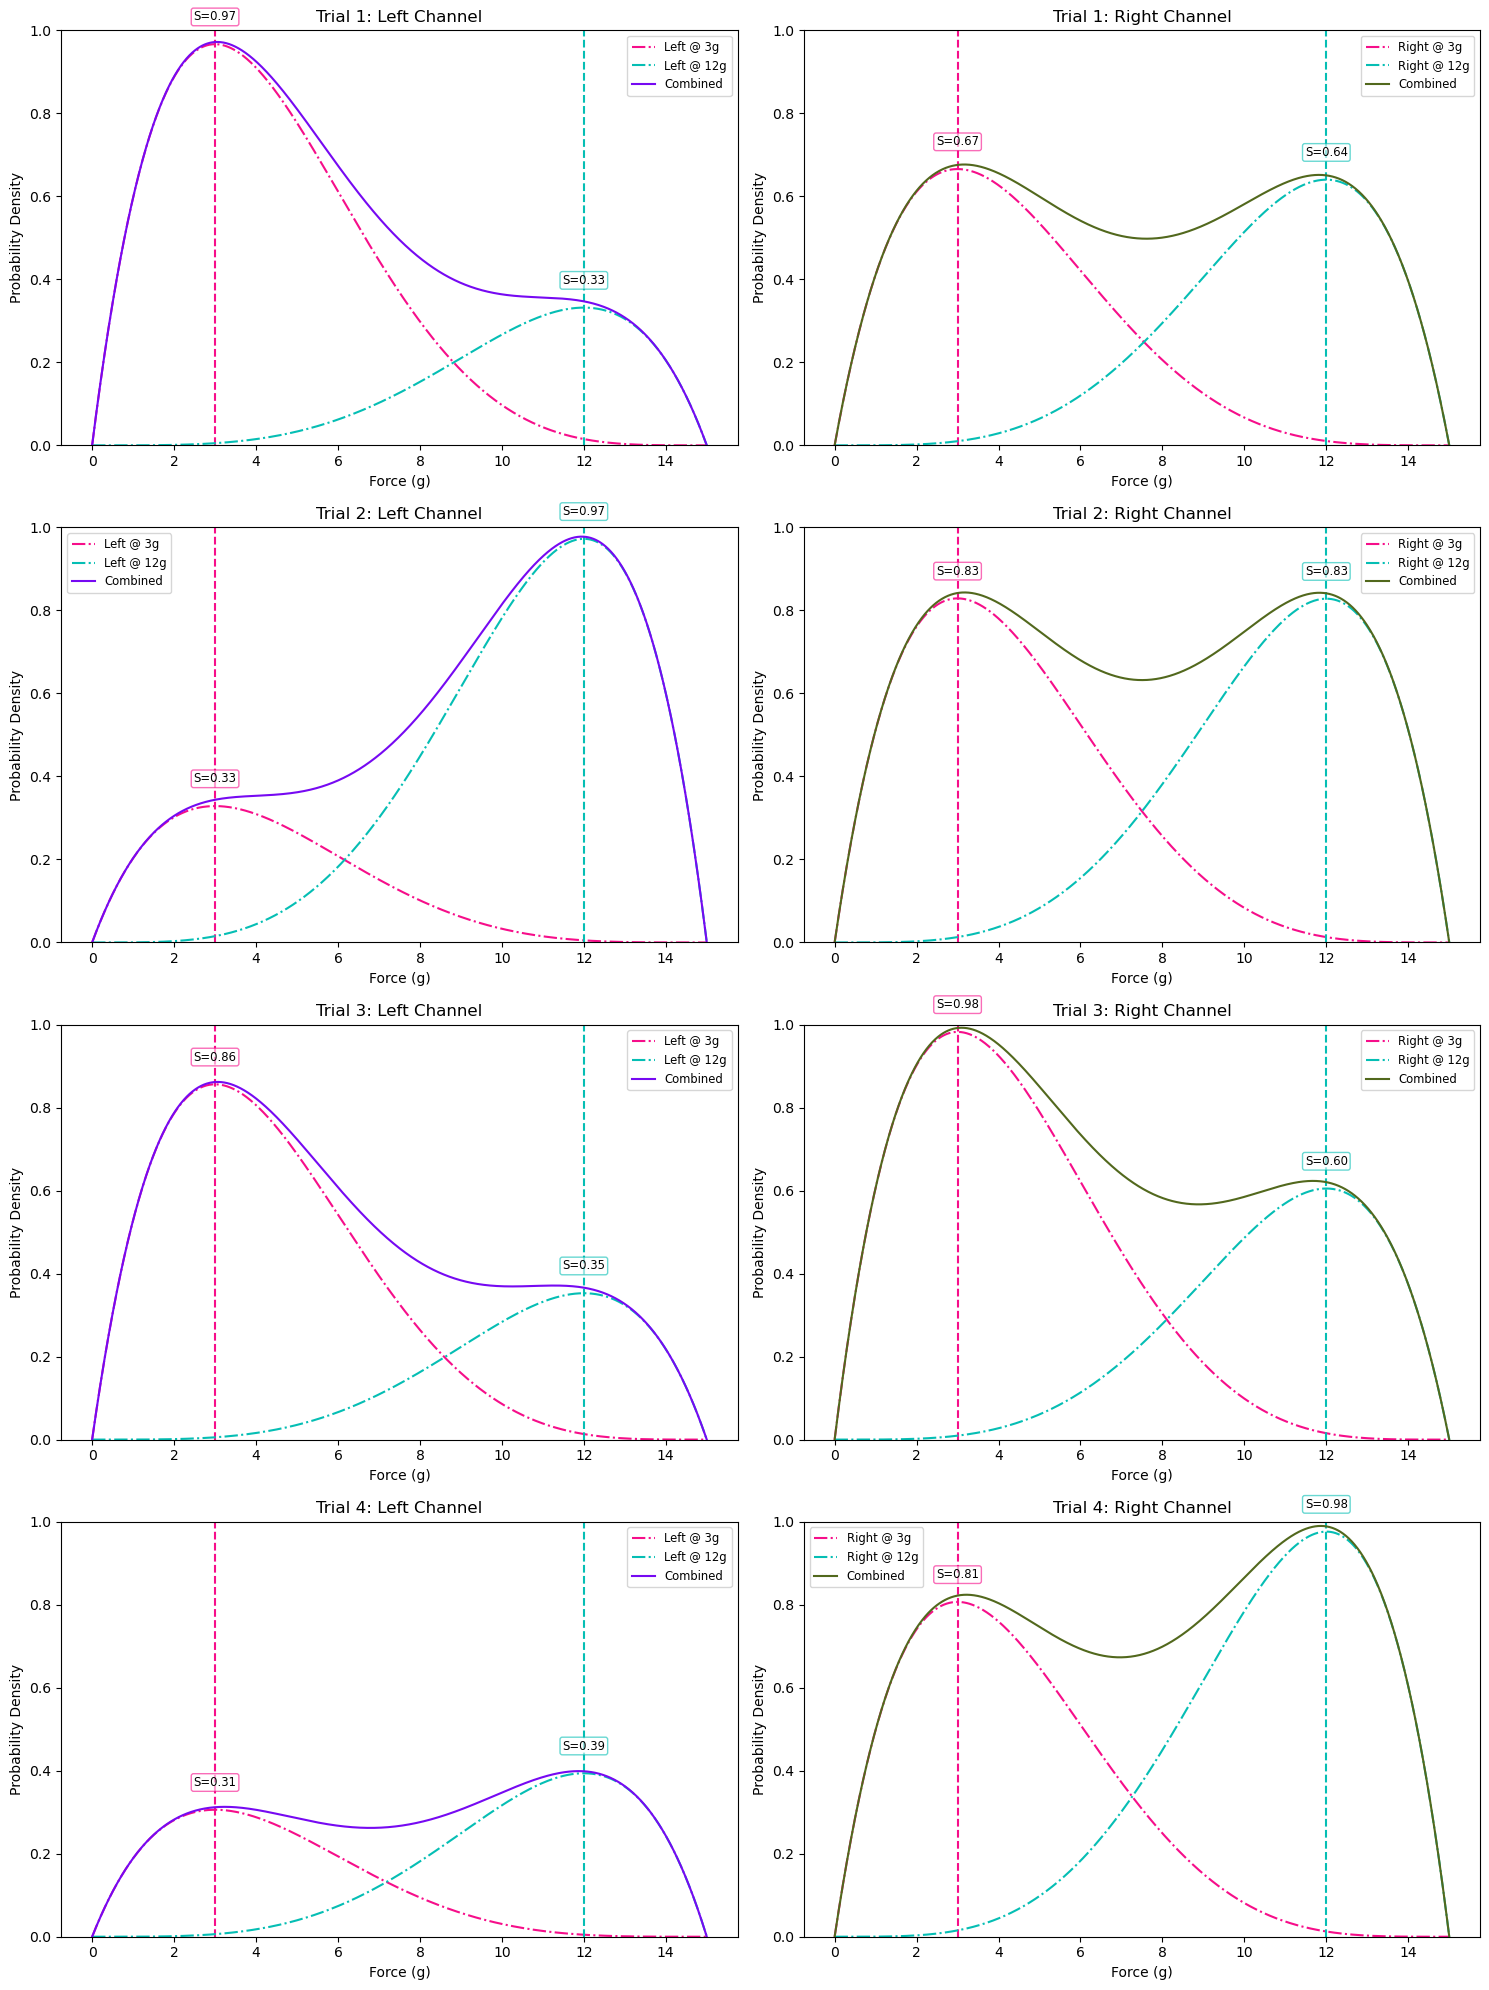

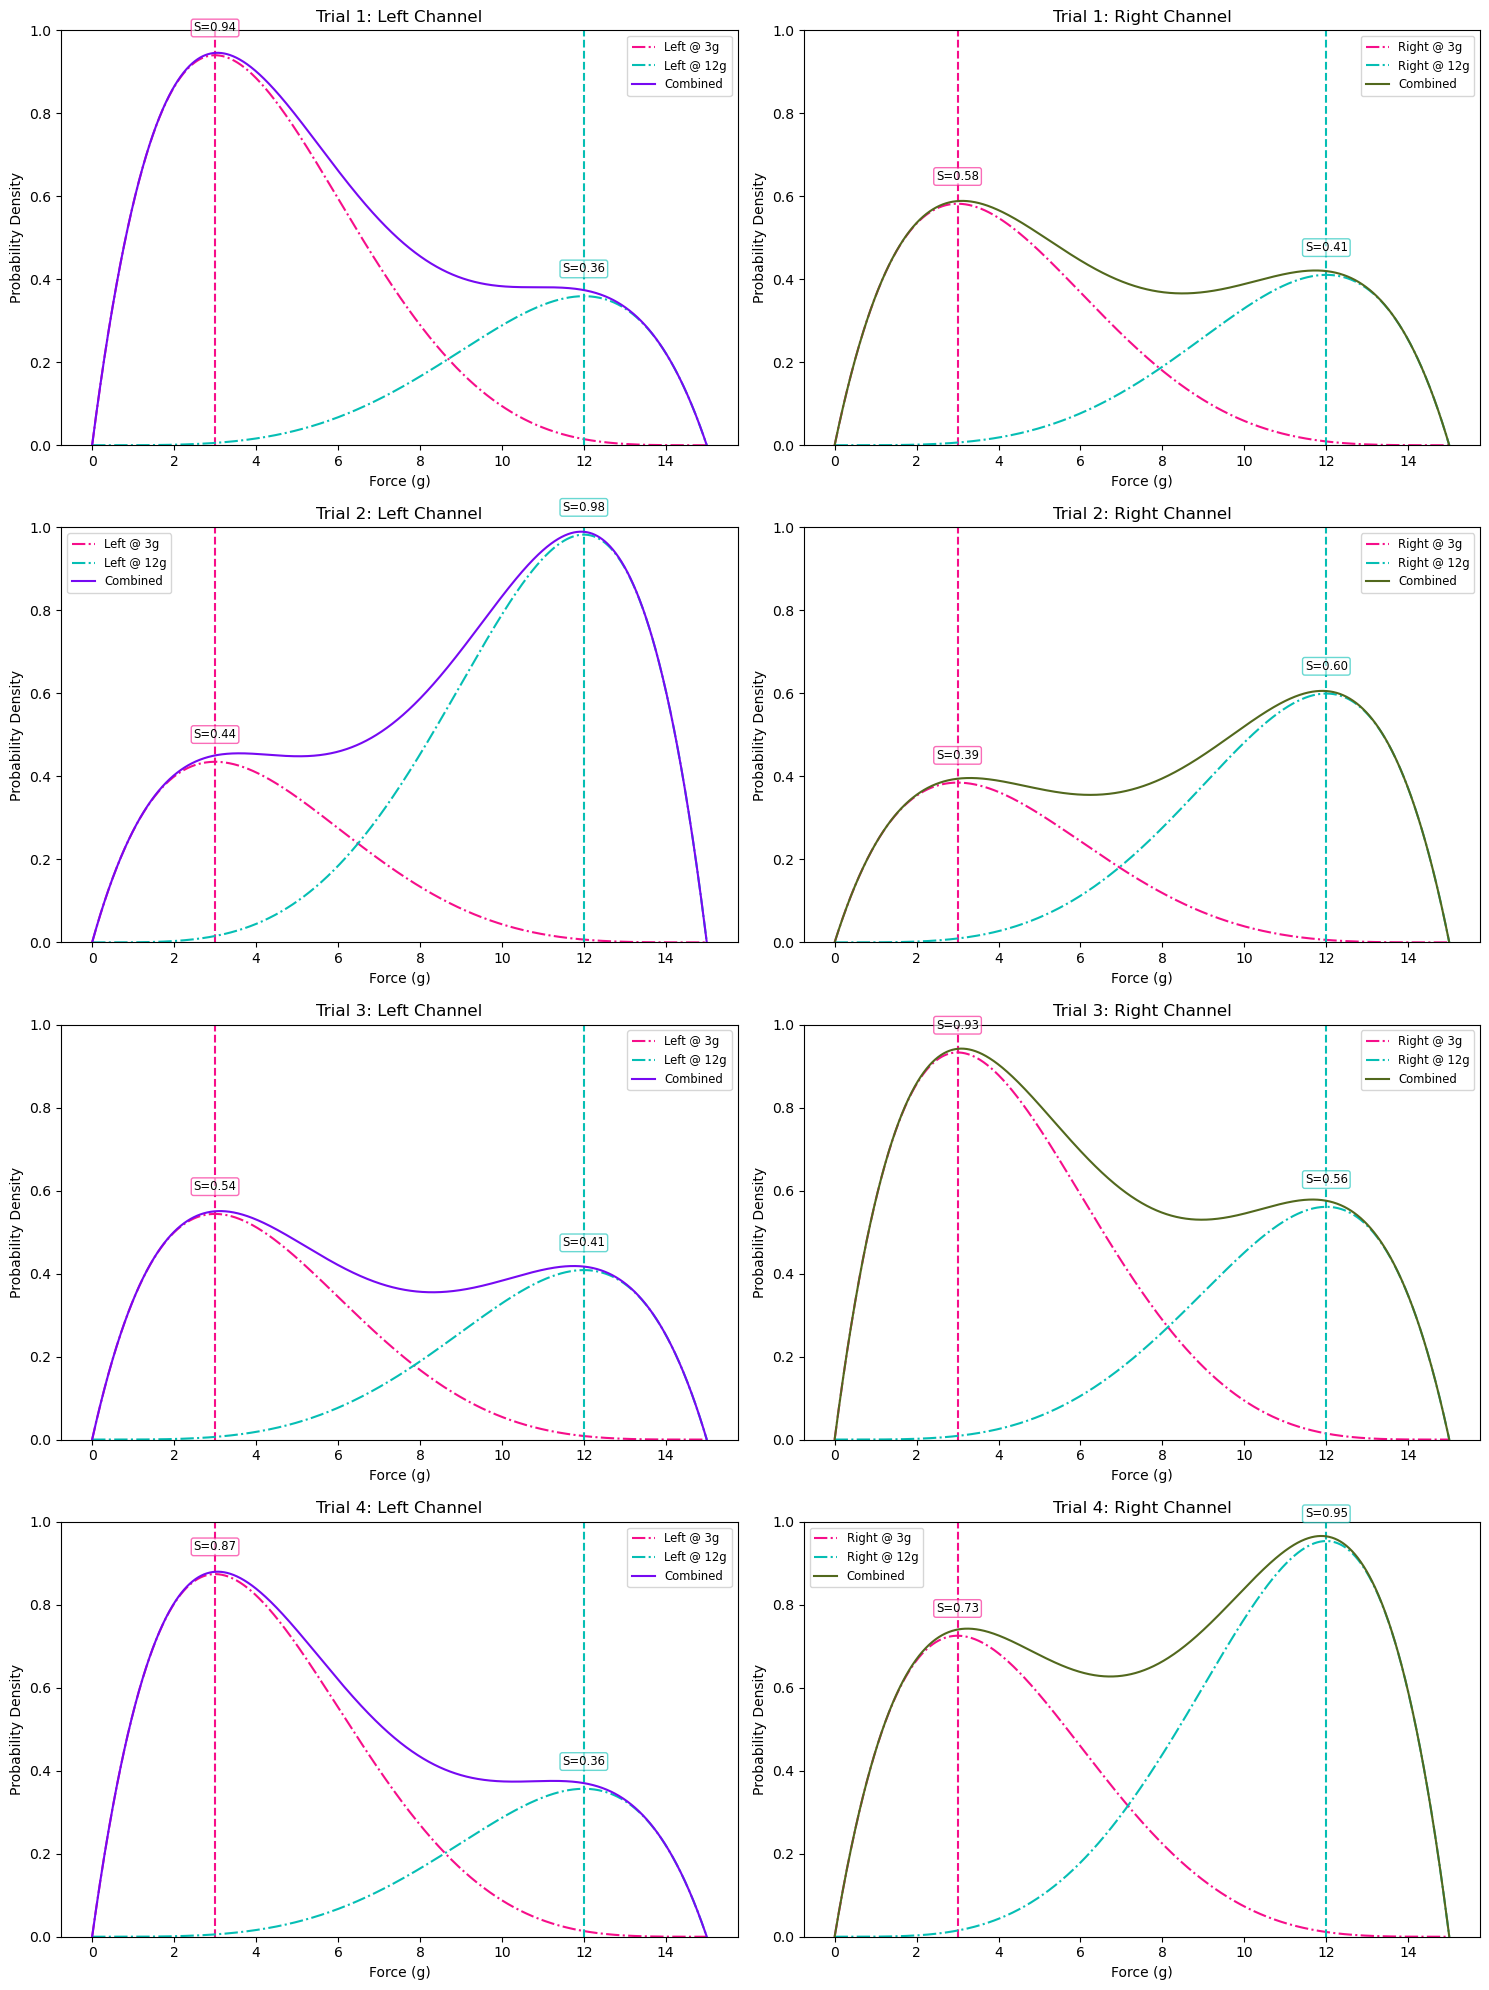

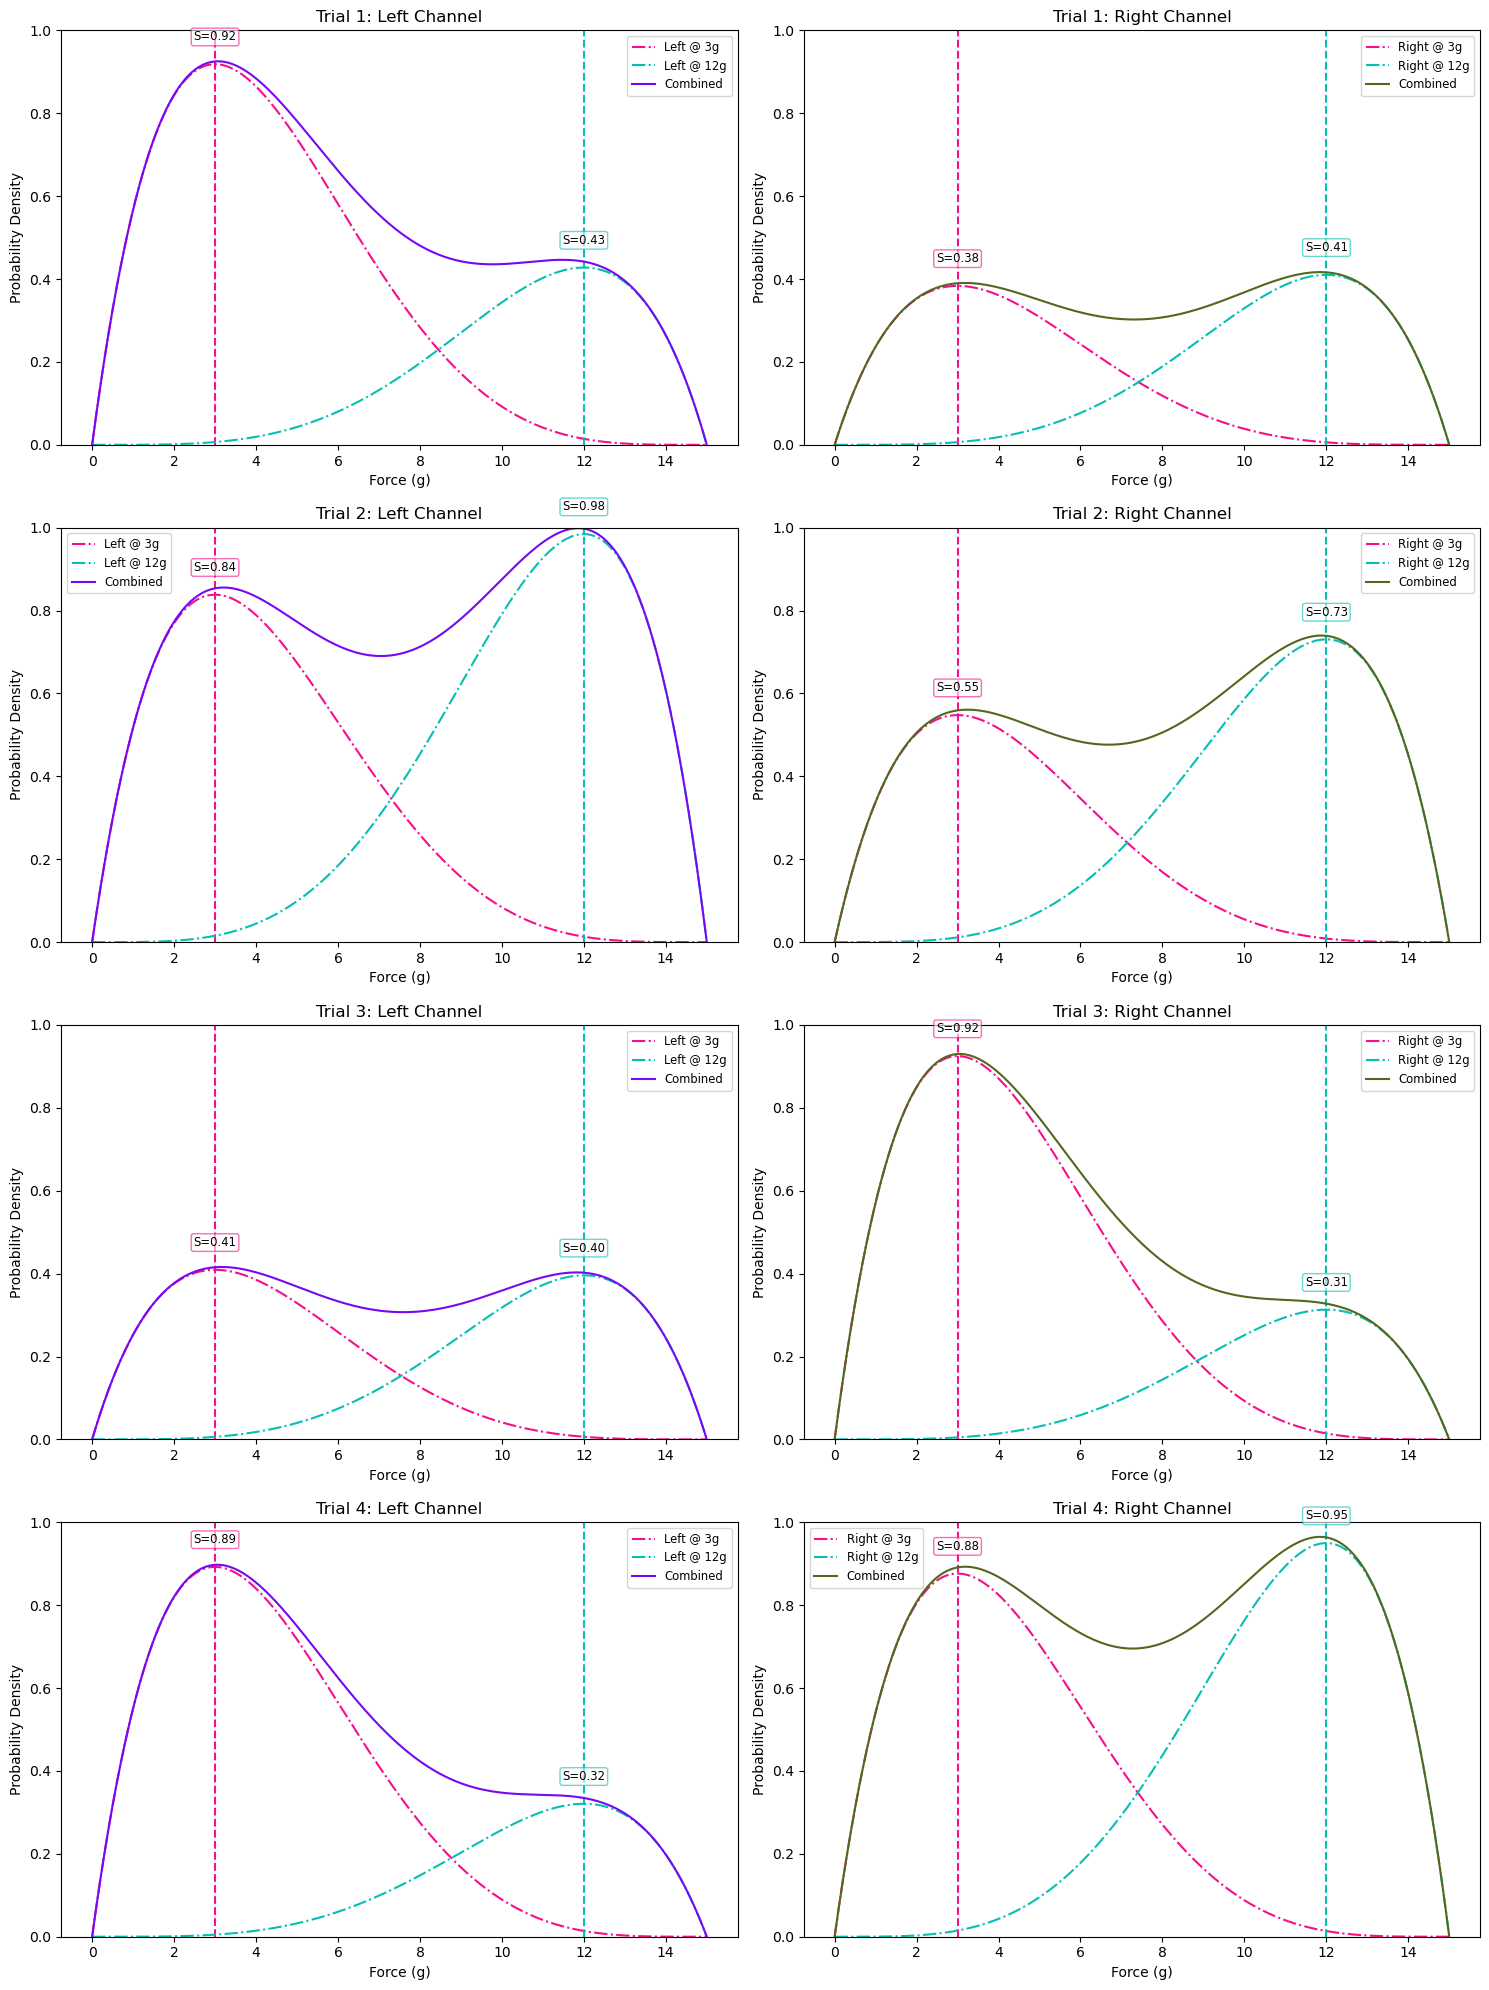

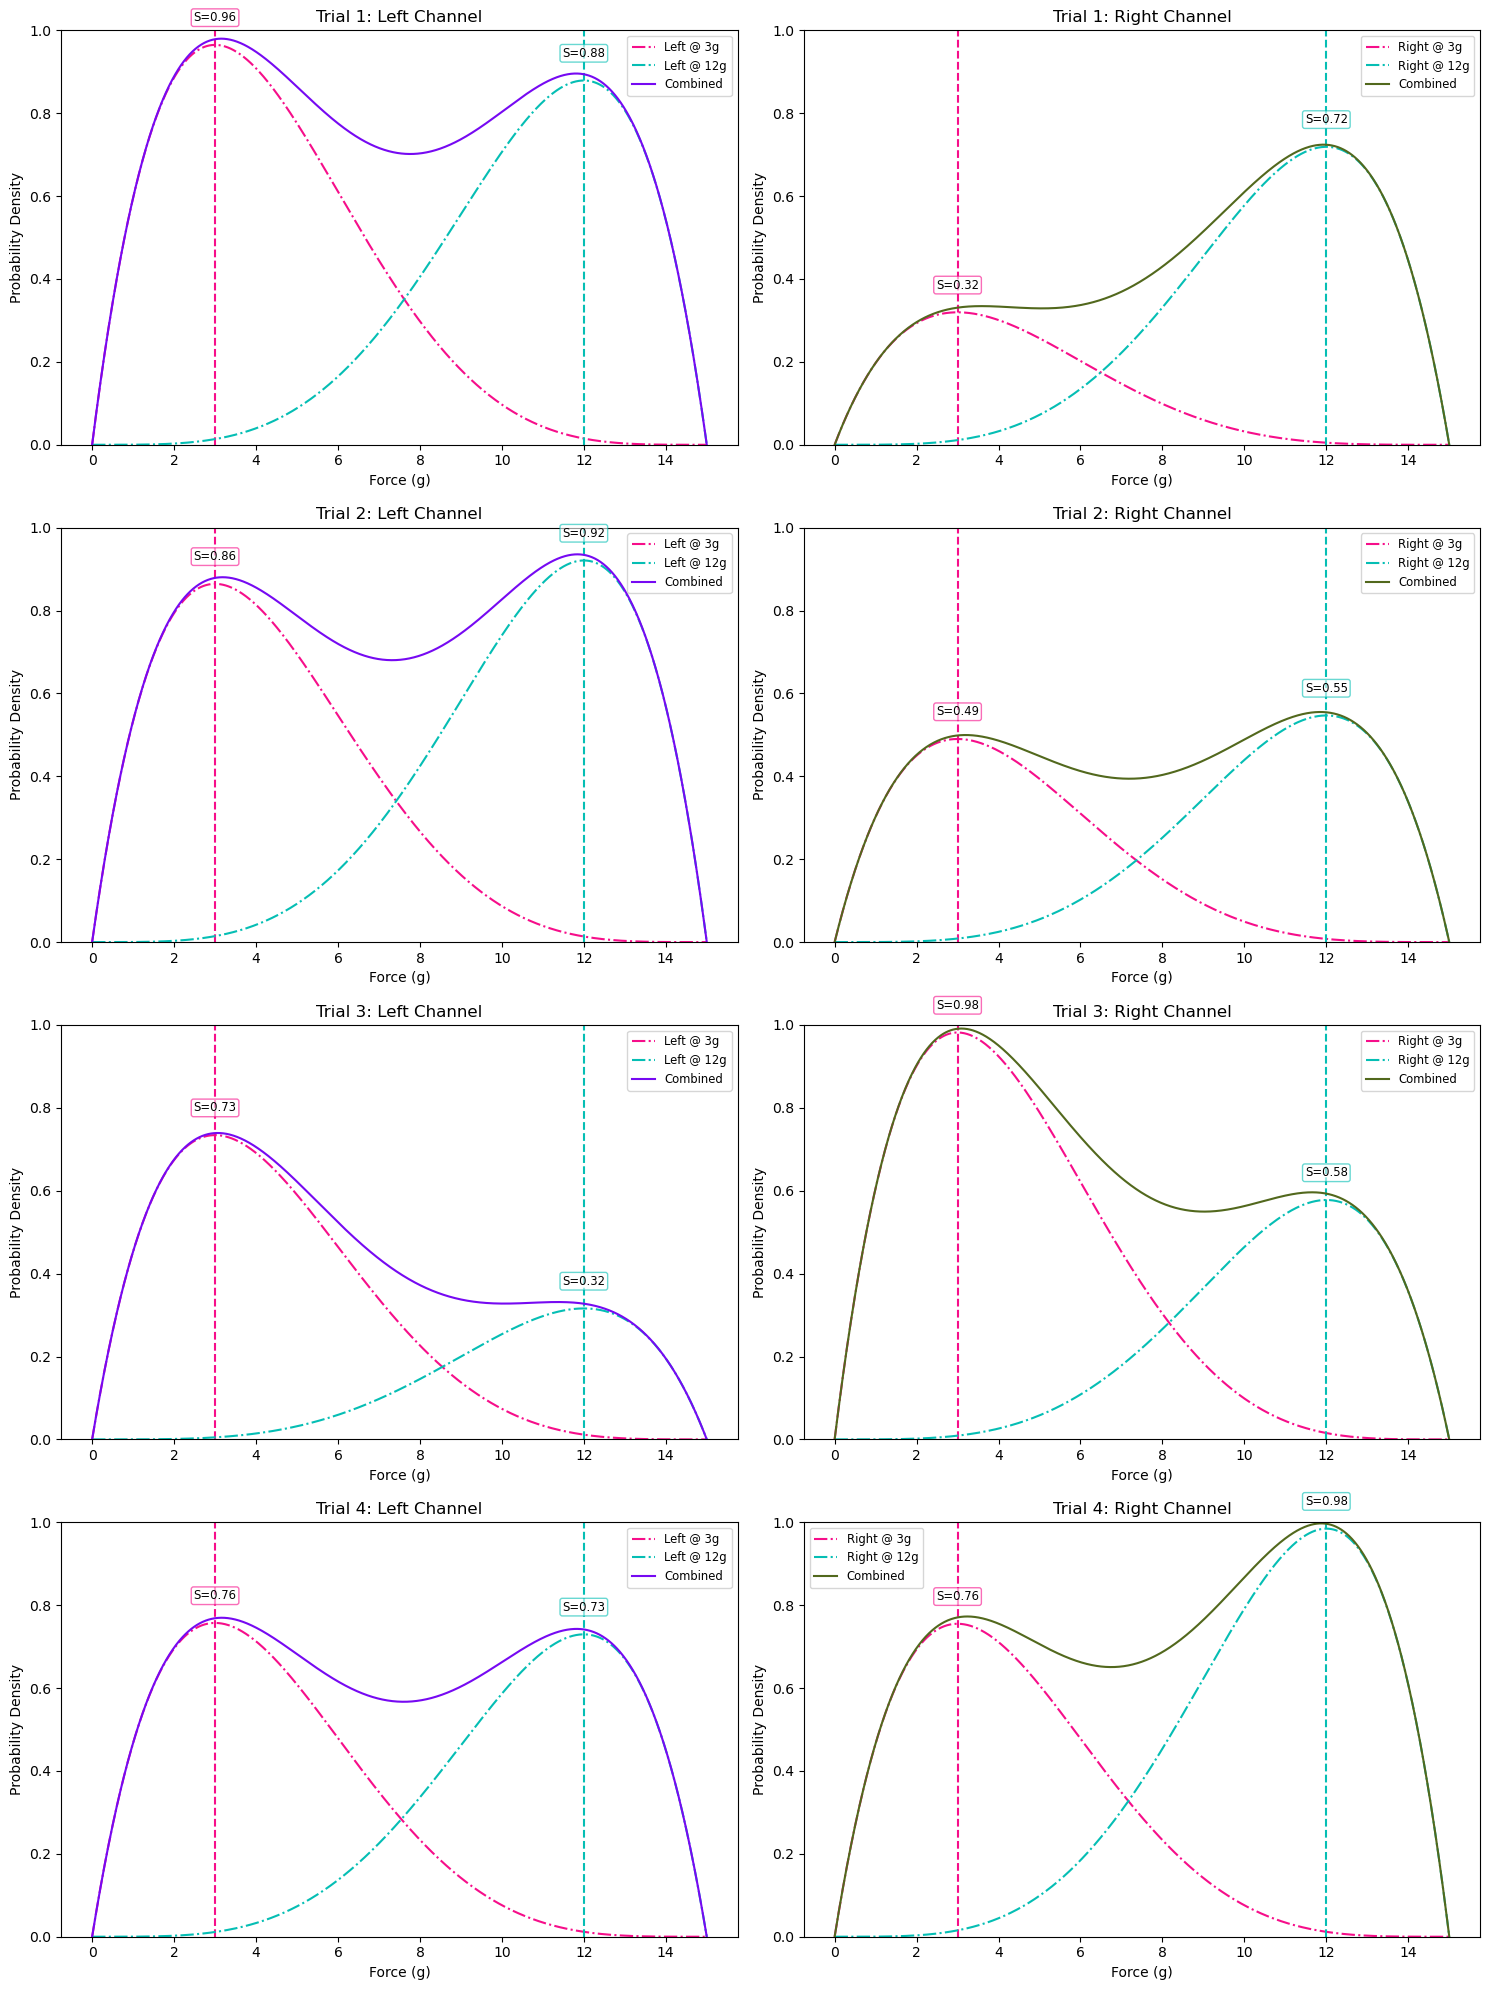

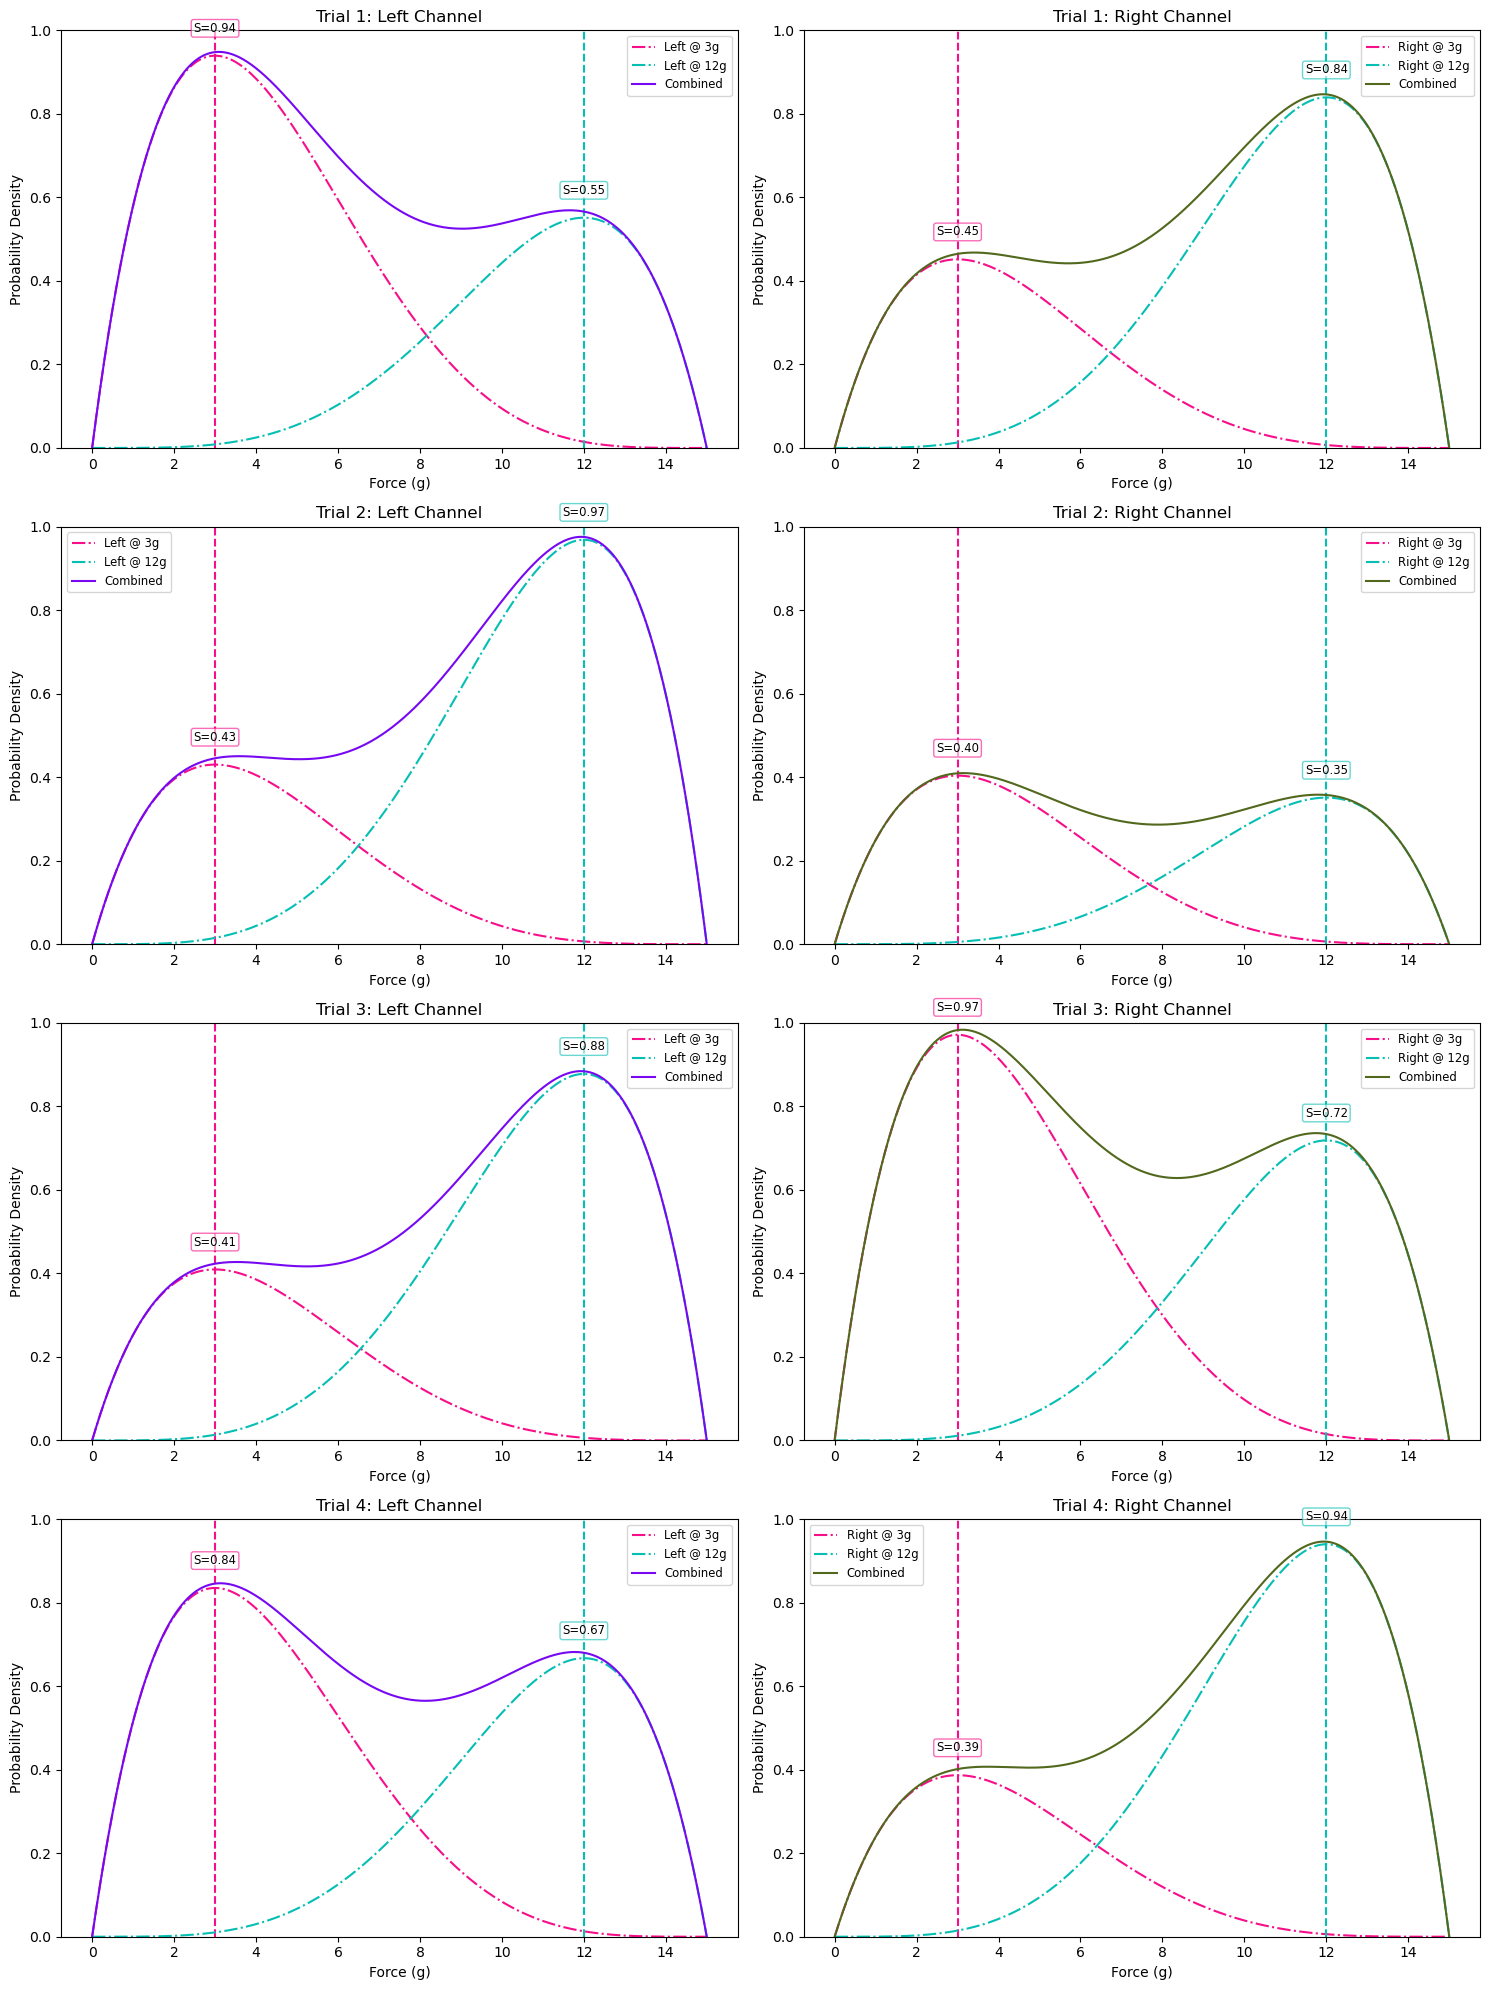

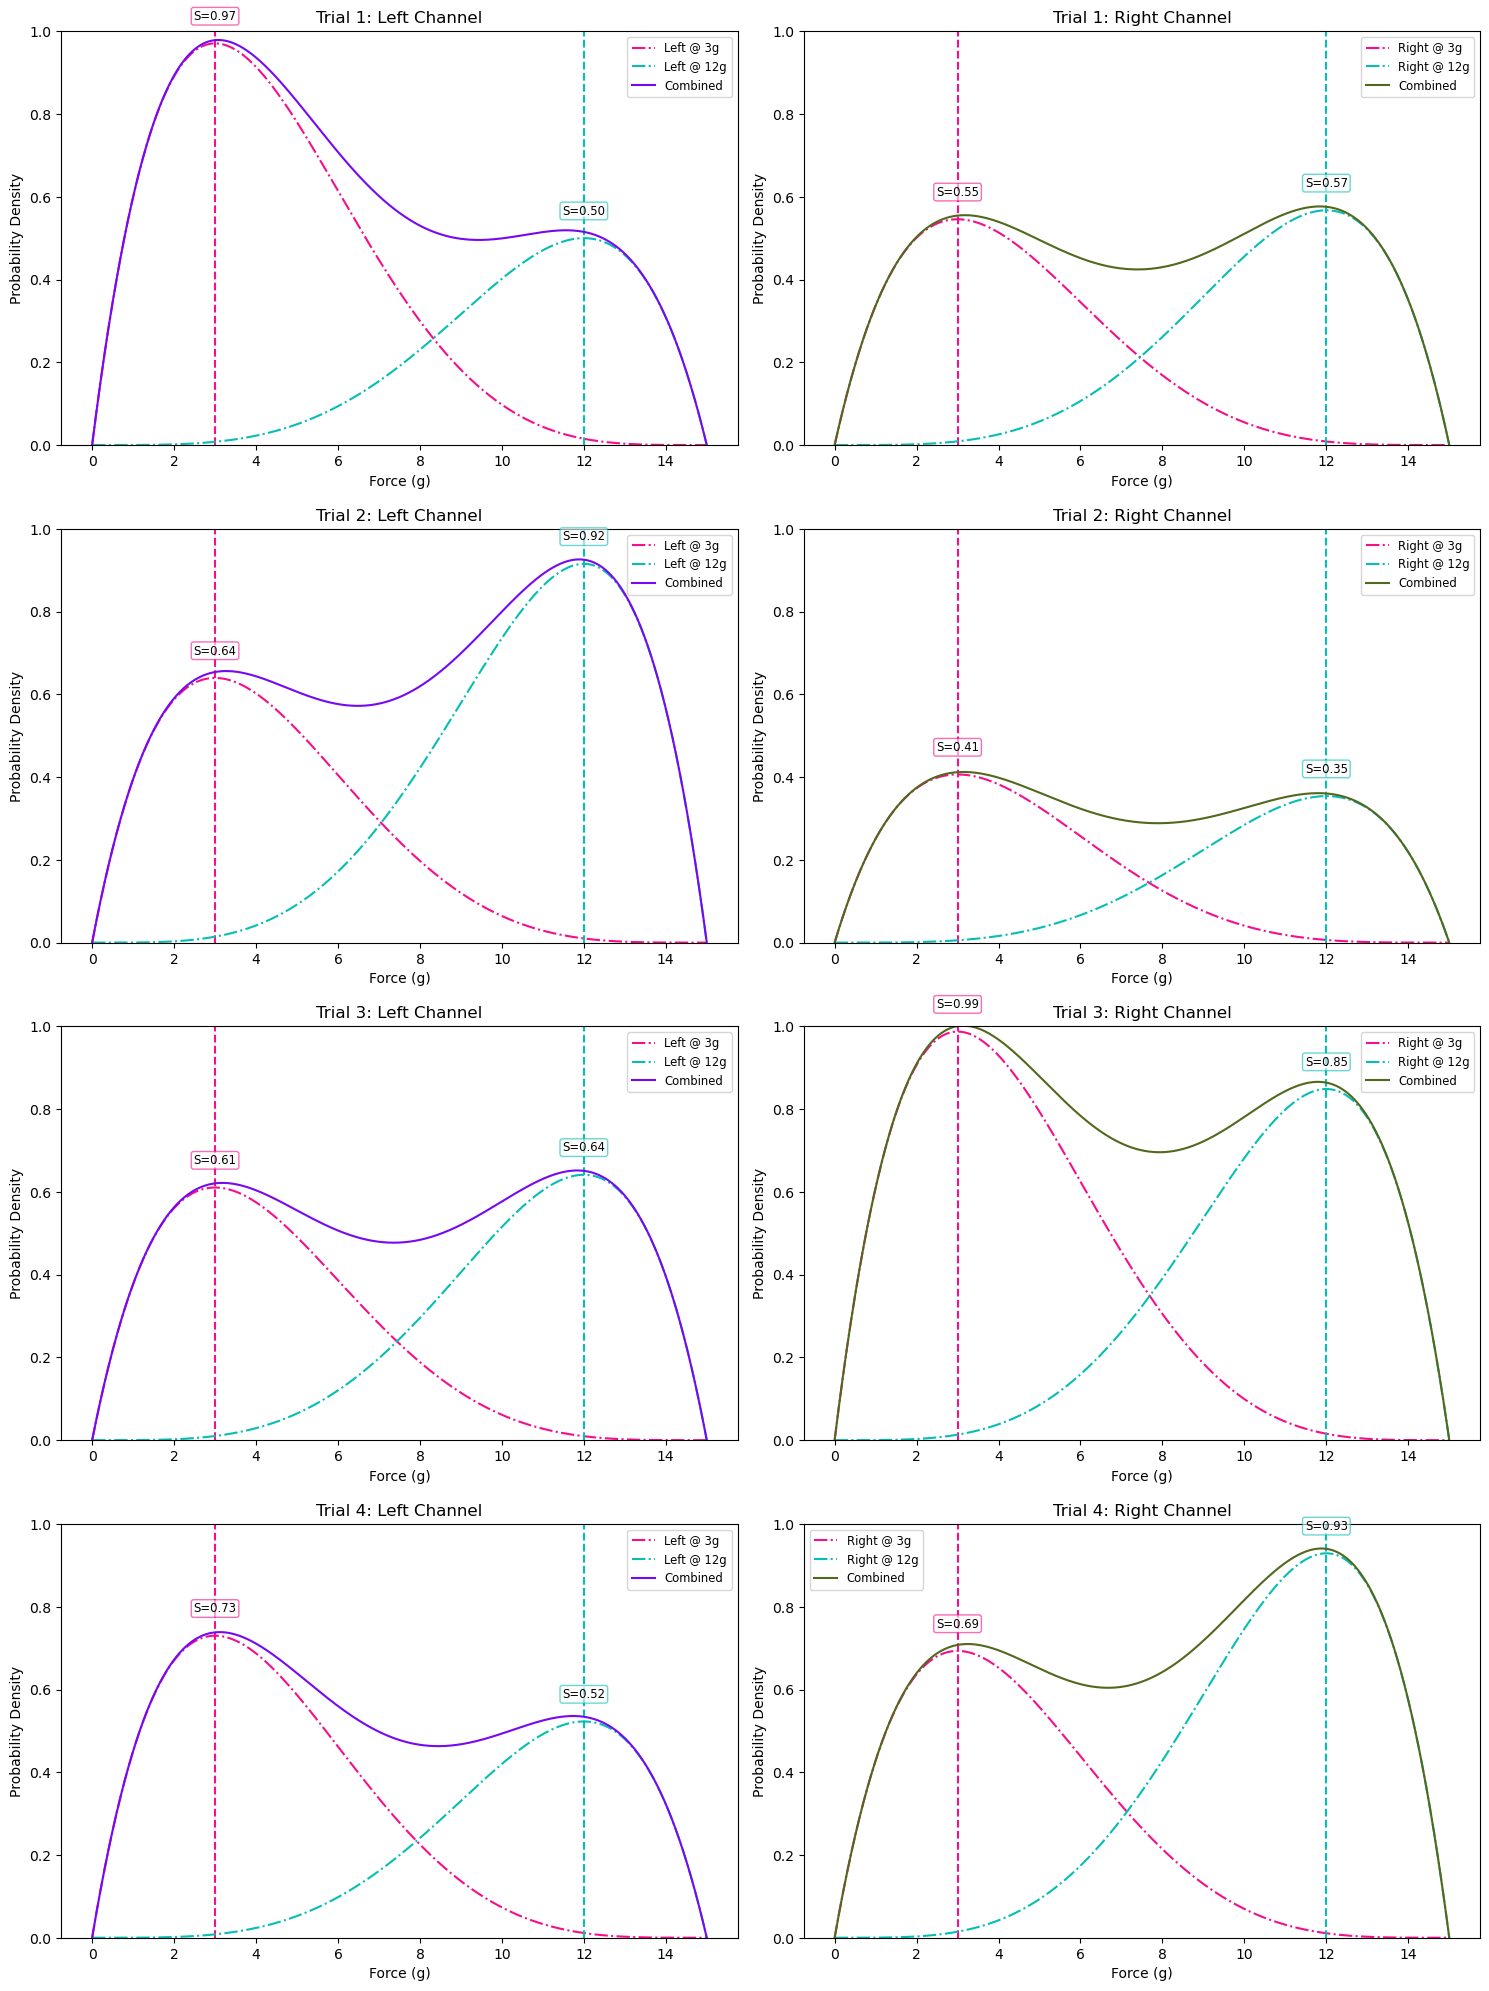

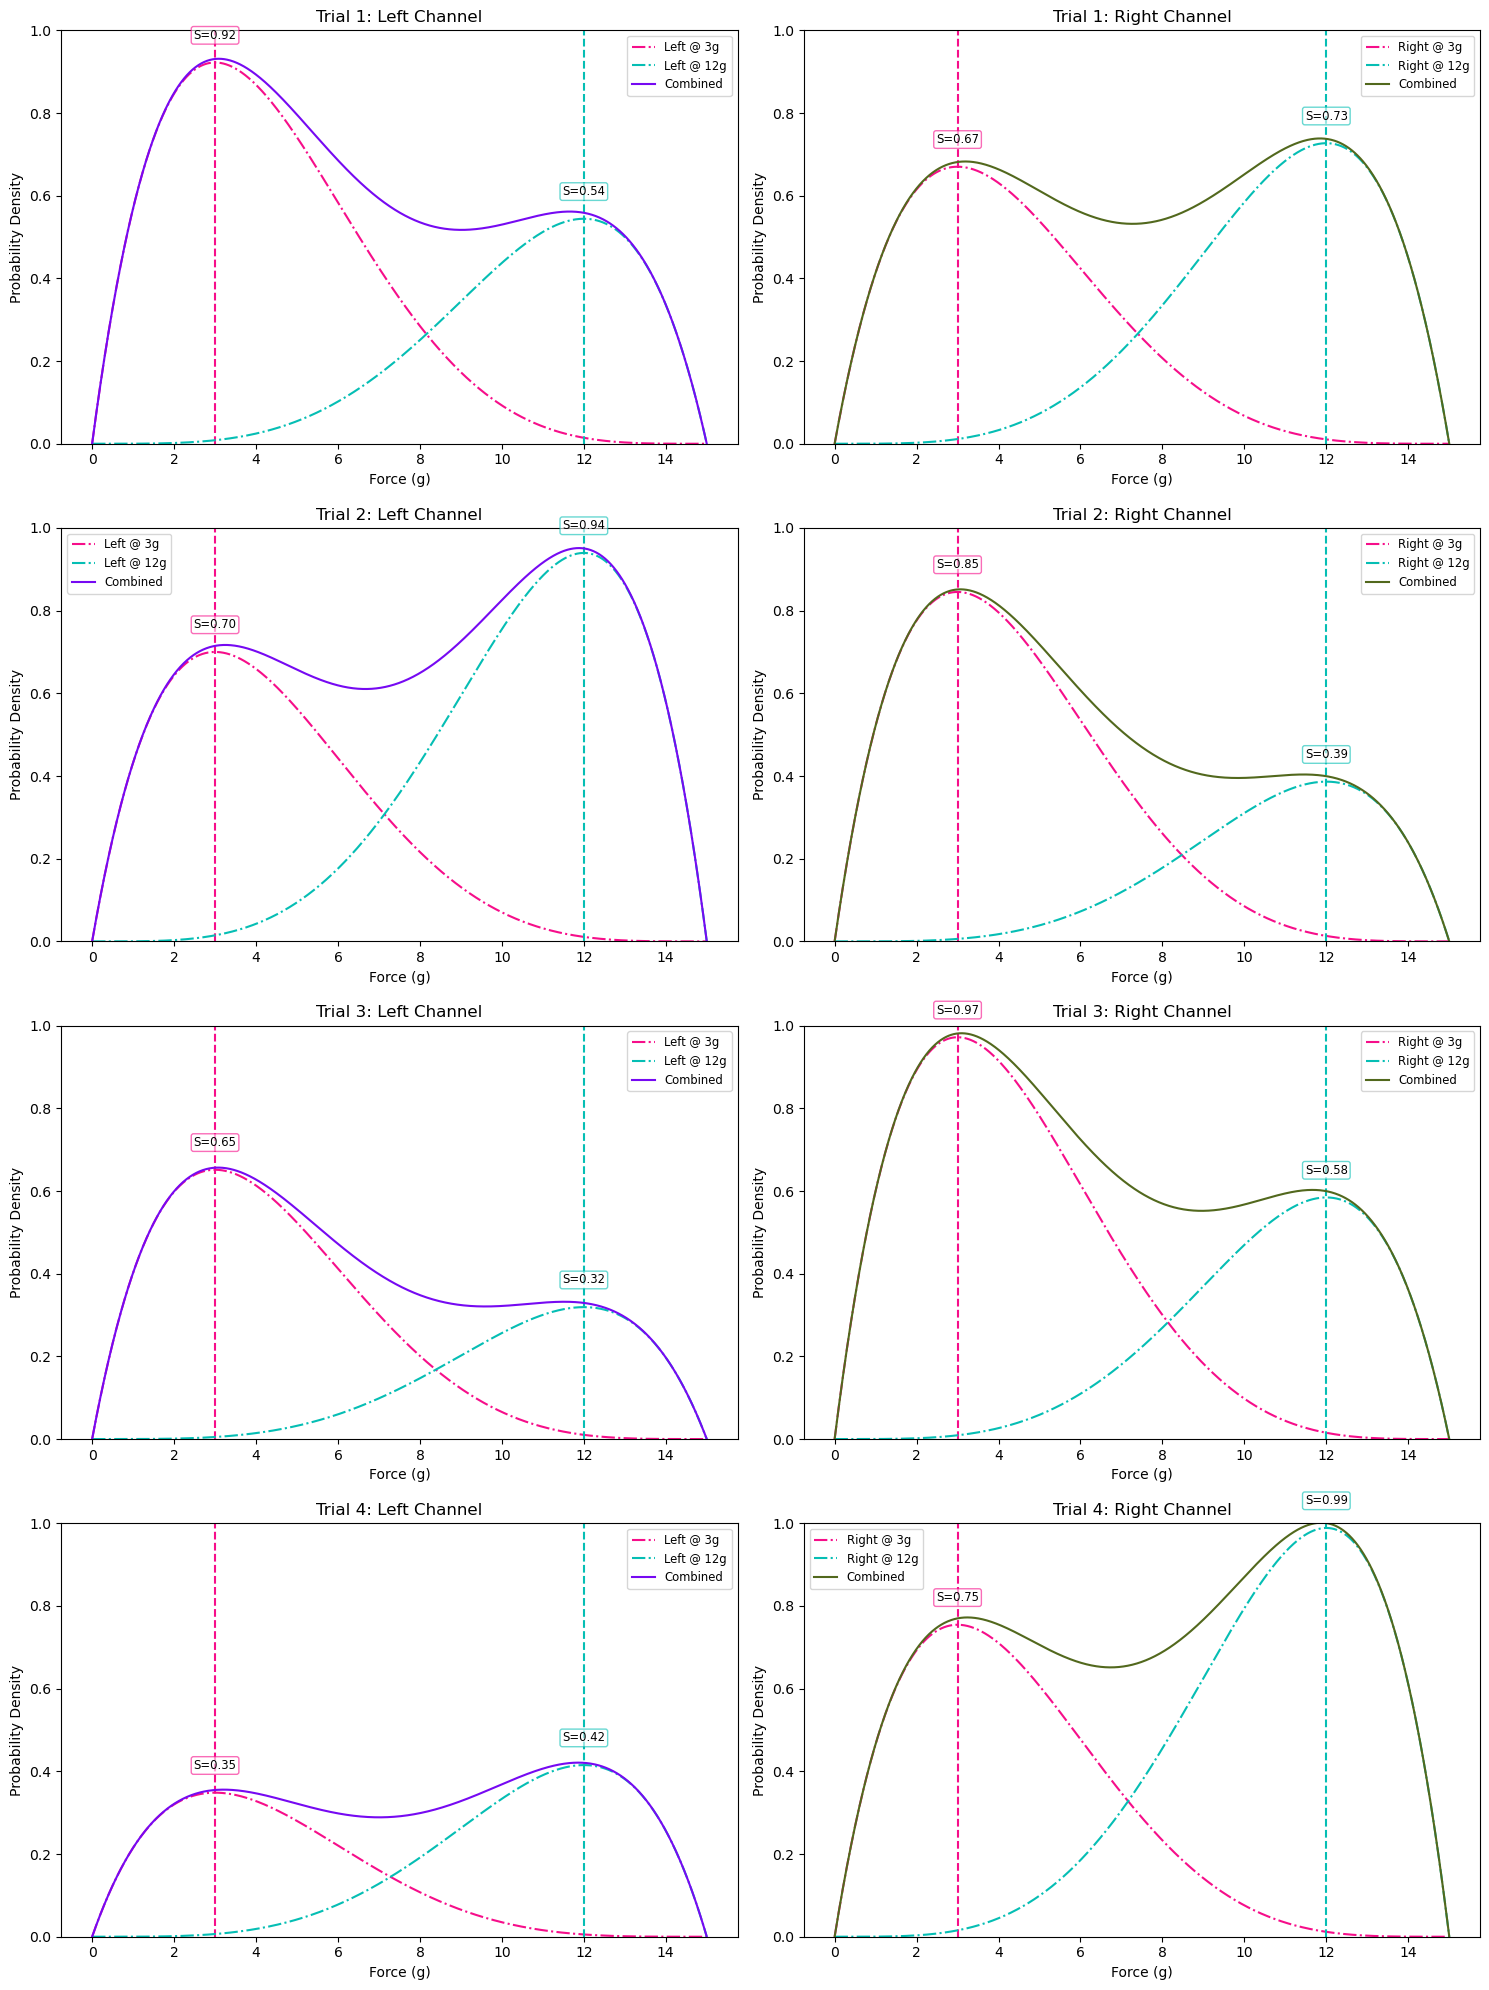

In [ ]:
from pathlib import Path
import json
import datetime as _dt
from utility import DataStorage


domain_force = np.linspace(0, 15, 1500)     # 1500 samples across 0–15 g
trial_template = Trial(
    dnf_params=dnf_params_park,
    n_actions=2,                             # Left & Right
    domain=domain_force,
    ssp_dim=512
)

# 3) Create and run the Session
session = Session(
    session_name="park_bimodal_pca_1.0",         # will save under bg_data/pca/park_bimodal_pca/
    n_sessions=10,
    Trial=trial_template,
    seed_base=20889604
)

written_paths = session.run(duration=1.0, presentation_time=1.0) 
# 0.5s: 18m, 40s run # 1s: 30m 1.4s

In [81]:
def _to_jsonable(x):
    # Make common non-JSON types serializable
    if isinstance(x, Path):
        return str(x)
    if hasattr(x, "tolist"):           # NumPy arrays, scalars
        return x.tolist()
    if isinstance(x, (set,)):
        return list(x)
    if isinstance(x, (_dt.date, _dt.datetime)):
        return x.isoformat()
    # Fallback: let json raise if truly unsupported
    raise TypeError(f"Object of type {type(x).__name__} is not JSON serializable")

out_path = Path('./bg_data/json/pca/written_paths.json')
out_path2 = Path('./bg_data/json/pca/written_paths1.0.json')
with out_path2.open("w", encoding="utf-8") as f:
        json.dump(written_paths, f, indent=2, ensure_ascii=False, default=_to_jsonable)

In [195]:
da = DataStorage()
h = da.load_json('bg_data/json/pca/park_bimodal_pca/00_foreground')
s = da.load_npz('bg_data/npz/pca/park_bimodal_pca/00_foreground.npz')

In [196]:
h[0]['session_data'][0].keys()

dict_keys(['name', 'meta', 'salience', 'bundles', 'bundle_ins', 'd1_input', 'd1_neuron', 'd2_input', 'd2_neuron', 'bundle_out', 'custom_probes'])

In [197]:
h[1]

{'kind': 'foreground',
 'session_index': 0,
 'seed': 1234,
 'session_name': 'park_bimodal_pca',
 'n_trials': 4,
 'created_utc': '2025-10-17T06:38:24Z',
 'format': 'json+npy',
 'version': '1.0',
 'run_id': 'pca/park_bimodal_pca/00_foreground'}

In [131]:
s[0]['session_data'][0]['d1_neuron'][50:][:, 1500:].shape

(150, 1500)

In [83]:
# Given written_paths read the data from there - either npz or json (using load_npz or load_json from DataStorage)
import json
from pathlib import Path

def load_json(path):
    path = Path(path)
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)   # -> Python dict / list

data_written_paths = load_json(out_path)

# ============================
# FOREGROUND DATA
# ============================
foreground_npz = [d['npz'][0] for d in data_written_paths]
foreground_json = [d['json'][0] for d in data_written_paths]

# ============================
# BACKGROUND DATA
# ============================
background_npz = [d['npz'][1] for d in data_written_paths]
background_json = [d['json'][1] for d in data_written_paths]

#=============
data_written_paths2 = load_json(out_path2)

# ============================
# FOREGROUND DATA
# ============================
foreground_npz1 = [d['npz'][0] for d in data_written_paths2]
foreground_json1 = [d['json'][0] for d in data_written_paths2]

# ============================
# BACKGROUND DATA
# ============================
background_npz1 = [d['npz'][1] for d in data_written_paths2]
background_json1 = [d['json'][1] for d in data_written_paths2]

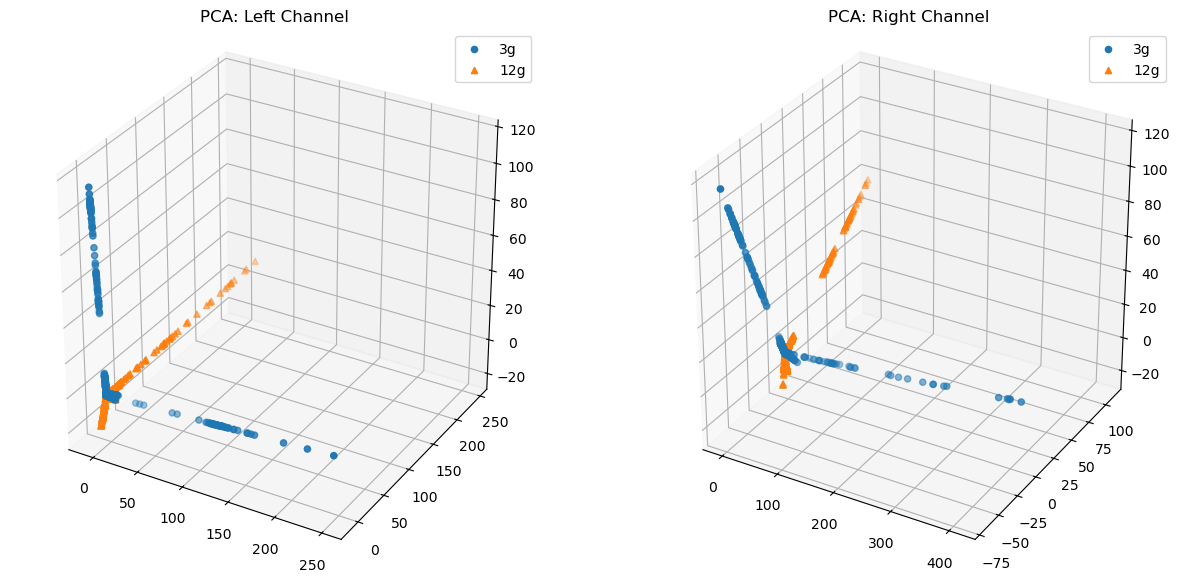

In [ ]:
# ============= PCA ==================== (0.5s)
pca_model = PCAAnalysis(n_components=3)
left, right, left_labels, right_labels = pca_model.data_format(data_type='npz', foreground_paths=foreground_npz, key = 'd1_neuron', discard=350, select=1500)
# Perform PCA analysis 
# Left channel 
left_pca = pca_model.pca(left) # (3000, 3)
# Right channel 
right_pca = pca_model.pca(right)
# in Jupyter
# 1) once per notebook:
# %pip install ipympl
# %matplotlib widget

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=(15, 8))

def plot_panel(ax, X, labels, title):
    m3  = labels == 3
    m12 = labels == 12
    ax.scatter(X[m3,0],  X[m3,1],  X[m3,2],  label='3g',  marker='o')
    ax.scatter(X[m12,0], X[m12,1], X[m12,2], label='12g', marker='^')
    ax.set_title(title)
    ax.legend()
    ax.set_box_aspect((1,1,1))  # nicer proportions

X1 = pca_model.to_real(left_pca)
X2 = pca_model.to_real(right_pca)   # (use right here; your snippet repeated left)
labels1 = np.asarray(left_labels)
labels2 = np.asarray(right_labels)

plot_panel(axes[0], X1, labels1, 'PCA: Left Channel')
plot_panel(axes[1], X2, labels2, 'PCA: Right Channel')
# plt.savefig('./figures/pca/session_pca.png')
plt.show()


[False False False ...  True  True  True]
[False False False ...  True  True  True]


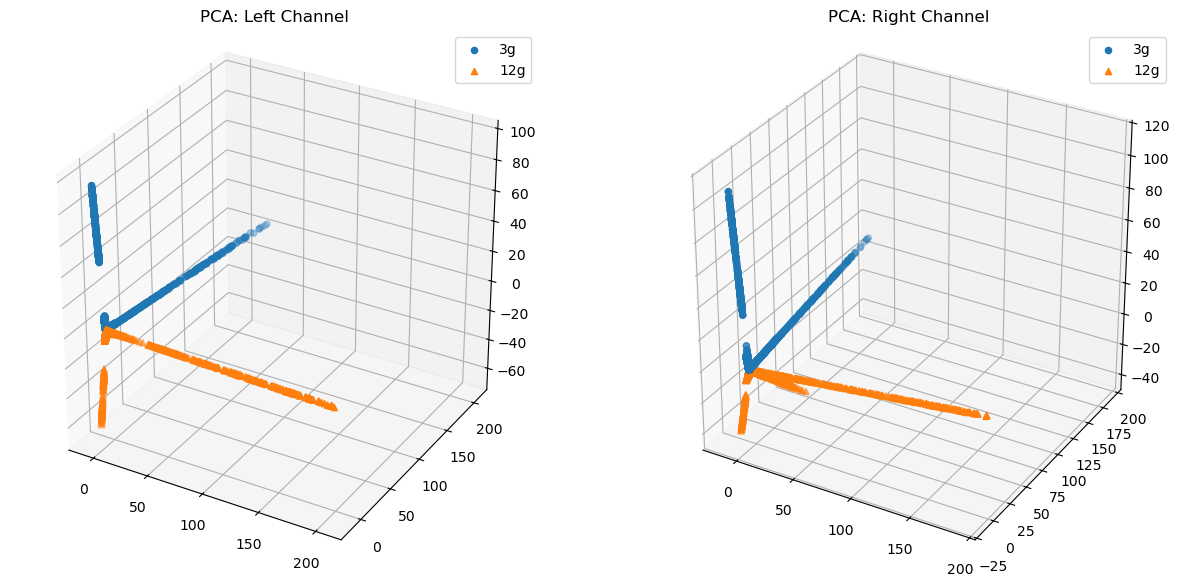

In [ ]:
# ============= PCA ==================== (1.0s)
pca_model1 = PCAAnalysis(n_components=3)
left1, right1, left_labels1, right_labels1 = pca_model.data_format(data_type='npz', foreground_paths=foreground_npz1, key = 'gpi', discard=500, select=1500)
# Perform PCA analysis 
# Left channel 
left_pca1 = pca_model.pca(left1)
# Right channel 
right_pca1 = pca_model.pca(right1)
# in Jupyter
# 1) once per notebook:
# %pip install ipympl
# %matplotlib widget

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=(15, 8))

def plot_panel(ax, X, labels, title):
    m3  = labels == 3
    m12 = labels == 12
    print(m12)
    ax.scatter(X[m3,0],  X[m3,1],  X[m3,2],  label='3g',  marker='o')
    ax.scatter(X[m12,0], X[m12,1], X[m12,2], label='12g', marker='^')
    ax.set_title(title)
    ax.legend()
    ax.set_box_aspect((1,1,1))  # nicer proportions

X11 = pca_model1.to_real(left_pca1)
X22 = pca_model.to_real(right_pca1)   # (use right here; your snippet repeated left)
labels11 = np.asarray(left_labels1)
labels22 = np.asarray(right_labels1)

plot_panel(axes[0], X11, labels11, 'PCA: Left Channel')
plot_panel(axes[1], X22, labels22, 'PCA: Right Channel')
# plt.savefig('./figures/pca/session_pca.png')
plt.show()


In [ ]:
# ========= CPCA ====================
cpca_model = cPCAAnalysis(n_components=3, standardize=True)
left_fg, right_fg, left_label_fg, right_label_fg = cpca_model.data_format(data_type='npz', foreground_paths=foreground_npz, 
                                                                          key='d1_neuron', discard=350, select=1500)
left_bg, right_bg, _, _ = cpca_model.data_format(data_type='npz', foreground_paths=background_npz,
                                                 key = 'd1_neuron', discard=350, select=1500)
# # Left channel cPCA
left_cpca, alpha_left = cpca_model.cpca(foreground_data=left_fg, background_data=left_bg, labels=left_label_fg, return_alpha=True)
# # Right channel cPCA
right_cpca, alpha_right = cpca_model.cpca(foreground_data=right_fg, background_data=right_bg, labels=right_label_fg, return_alpha=True)

/Users/priyadarshinisaha/anaconda3/envs/bgmodel/lib/python3.10/site-packages/contrastive/__init__.py:40: RuntimeWarning: divide by zero encountered in divide
  standardized_array =  (array-np.mean(array,axis=0)) / np.std(array,axis=0)
/Users/priyadarshinisaha/anaconda3/envs/bgmodel/lib/python3.10/site-packages/contrastive/__init__.py:40: RuntimeWarning: invalid value encountered in divide
  standardized_array =  (array-np.mean(array,axis=0)) / np.std(array,axis=0)
/Users/priyadarshinisaha/anaconda3/envs/bgmodel/lib/python3.10/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/priyadarshinisaha/anaconda3/envs/bgmodel/lib/python3.10/site-packages/numpy/core/_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/Users/priyadarshinisaha/anaconda3/envs/bgmodel/lib/python3.10/site-packages/sklearn/utils/extmath.

ValueError: array must not contain infs or NaNs

In [75]:

import numpy as np

def _finite_clip(x, lo=-1e6, hi=1e6):
    # Replace NaN/Inf and clip extreme magnitudes to keep SVD well-conditioned
    x = np.asarray(x, dtype=np.float64)
    x = np.nan_to_num(x, neginf=lo, posinf=hi)
    return np.clip(x, lo, hi)

def _standardize_safe(X, ref=None, eps=1e-12, clip_z=8.0):
    """
    Z-score columns with zero-variance protection.
    If ref is provided, use (mu, sigma) computed from ref (e.g., background).
    Returns (Z, keep_mask, mu, sigma).
    """
    X = np.asarray(X, dtype=np.float64)

    if ref is None:
        mu = np.nanmean(X, axis=0)
        sigma = np.nanstd(X, axis=0)
    else:
        ref = np.asarray(ref, dtype=np.float64)
        mu = np.nanmean(ref, axis=0)
        sigma = np.nanstd(ref, axis=0)

    keep = sigma > eps                     # drop constant columns
    mu, sigma = mu[keep], sigma[keep]
    Z = (X[:, keep] - mu) / sigma
    Z = np.clip(np.nan_to_num(Z), -clip_z, clip_z)
    return Z, keep, mu, sigma

def prepare_fg_bg_for_cpca(FG, BG):
    """
    Sanitize + standardize foreground and background consistently.
    Uses BG statistics (common in contrastive setups).
    Ensures FG and BG end up with the *same* feature subset.
    """
    FG = _finite_clip(FG)
    BG = _finite_clip(BG)

    # Compute keep mask from BG; also ensure finite variance on FG for same columns
    Zbg_tmp, keep_bg, mu_bg, sigma_bg = _standardize_safe(BG, ref=BG)
    # Check FG variance on the kept cols (rarely needed, but safe)
    fg_std = np.nanstd(FG[:, keep_bg], axis=0)
    keep_both = keep_bg.copy()
    keep_both[keep_bg] &= (fg_std > 1e-12)

    # Final standardization using BG stats on intersected columns
    mu = mu_bg[fg_std > 1e-12]
    sigma = sigma_bg[fg_std > 1e-12]
    Zbg = (BG[:, keep_both] - mu) / sigma
    Zfg = (FG[:, keep_both] - mu) / sigma

    Zbg = np.clip(np.nan_to_num(Zbg), -8, 8)
    Zfg = np.clip(np.nan_to_num(Zfg), -8, 8)
    return Zfg, Zbg, keep_both

# ========= CPCA ====================
# cpca_model = cPCAAnalysis(n_components=3, standardize=False)
# left_fg, right_fg, left_label_fg, right_label_fg = cpca_model.data_format(data_type='npz', foreground_paths=foreground_npz, 
#                                                                           key='d1_neuron', discard=350, select=1500)
# left_bg, right_bg, _, _ = cpca_model.data_format(data_type='npz', foreground_paths=background_npz,
#                                                  key = 'd1_neuron', discard=350, select=1500)
# # # Left channel cPCA
# left_cpca, alpha_left = cpca_model.cpca(foreground_data=left_fg, background_data=left_bg, labels=left_label_fg, return_alpha=True)
# # # Right channel cPCA
# right_cpca, alpha_right = cpca_model.cpca(foreground_data=right_fg, background_data=right_bg, labels=right_label_fg, return_alpha=True)

# 1) Get raw matrices from your loader
left_fg, right_fg, left_label_fg, right_label_fg = cpca_model.data_format(
    data_type='npz', foreground_paths=foreground_npz, key='d1_neuron', discard=350, select=1500
)
left_bg, right_bg, _, _ = cpca_model.data_format(
    data_type='npz', foreground_paths=background_npz, key='d1_neuron', discard=350, select=1500
)

# 2) Sanitize + safe-standardize (use background stats)
left_fg_z,  left_bg_z,  _ = prepare_fg_bg_for_cpca(left_fg,  left_bg)
right_fg_z, right_bg_z, _ = prepare_fg_bg_for_cpca(right_fg, right_bg)

# 3) Turn OFF the package’s internal standardization and run cPCA
cpca_model = cPCAAnalysis(n_components=3, standardize=False)

left_cpca,  alpha_left  = cpca_model.cpca(foreground_data=left_fg_z,  background_data=left_bg_z,
                                          labels=left_label_fg,  return_alpha=True)
right_cpca, alpha_right = cpca_model.cpca(foreground_data=right_fg_z, background_data=right_bg_z,
                                          labels=right_label_fg, return_alpha=True)




(2, 4)


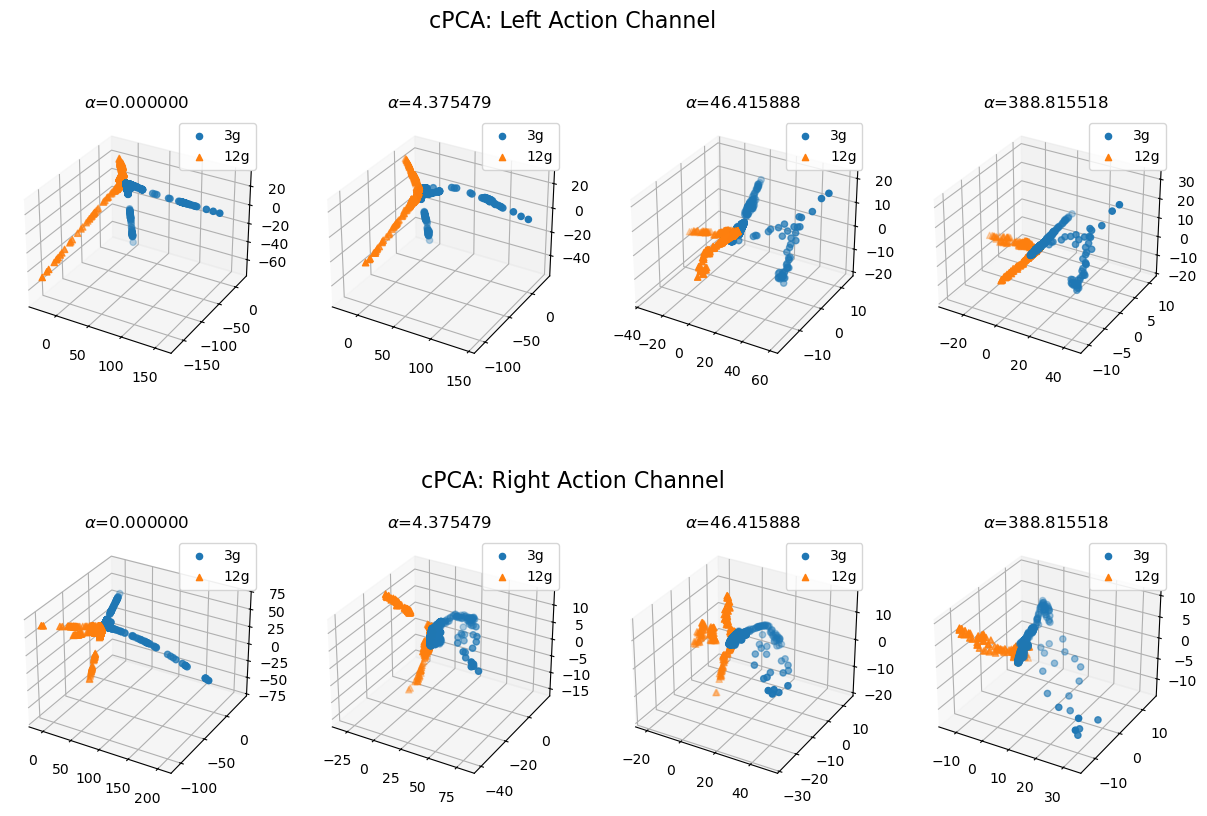

In [76]:
# LEFT GRAPHS
fig, axes = plt.subplots(2, len(alpha_left), subplot_kw={'projection': '3d'}, figsize=(15, 10))
print(axes.shape)
def projected_data_3dplots(axes, data, alphas, labels, titles):
    for i in range(len(alphas)):
        # convert the data into real data 
        X = cpca_model.to_real(data[i])
        graph_labels = np.asarray(labels)
        f3 = graph_labels == 3
        f12 = graph_labels == 12
        # plot 
        axes[i].scatter(X[f3, 0],  X[f3, 1],  X[f3, 2],  label='3g',  marker='o')
        axes[i].scatter(X[f12, 0], X[f12, 1], X[f12, 2], label='12g', marker='^')
        axes[i].set_title(r'$\alpha$=' + f'{alpha_left[i]:2f}')
        axes[i].legend()


projected_data_3dplots(axes[0, :], left_cpca, alpha_left, left_label_fg, titles=[])
projected_data_3dplots(axes[1, :], right_cpca, alpha_right, right_label_fg, titles=[])

fig.text(0.5, 0.92, "cPCA: Left Action Channel", ha='center', fontsize=16)
fig.text(0.5, 0.46, "cPCA: Right Action Channel", ha='center', fontsize=16)
plt.show()

In [101]:

import numpy as np

def _finite_clip(x, lo=-1e6, hi=1e6):
    # Replace NaN/Inf and clip extreme magnitudes to keep SVD well-conditioned
    x = np.asarray(x, dtype=np.float64)
    x = np.nan_to_num(x, neginf=lo, posinf=hi)
    return np.clip(x, lo, hi)

def _standardize_safe(X, ref=None, eps=1e-12, clip_z=8.0):
    """
    Z-score columns with zero-variance protection.
    If ref is provided, use (mu, sigma) computed from ref (e.g., background).
    Returns (Z, keep_mask, mu, sigma).
    """
    X = np.asarray(X, dtype=np.float64)

    if ref is None:
        mu = np.nanmean(X, axis=0)
        sigma = np.nanstd(X, axis=0)
    else:
        ref = np.asarray(ref, dtype=np.float64)
        mu = np.nanmean(ref, axis=0)
        sigma = np.nanstd(ref, axis=0)

    keep = sigma > eps                     # drop constant columns
    mu, sigma = mu[keep], sigma[keep]
    Z = (X[:, keep] - mu) / sigma
    Z = np.clip(np.nan_to_num(Z), -clip_z, clip_z)
    return Z, keep, mu, sigma

def prepare_fg_bg_for_cpca(FG, BG):
    """
    Sanitize + standardize foreground and background consistently.
    Uses BG statistics (common in contrastive setups).
    Ensures FG and BG end up with the *same* feature subset.
    """
    FG = _finite_clip(FG)
    BG = _finite_clip(BG)

    # Compute keep mask from BG; also ensure finite variance on FG for same columns
    Zbg_tmp, keep_bg, mu_bg, sigma_bg = _standardize_safe(BG, ref=BG)
    # Check FG variance on the kept cols (rarely needed, but safe)
    fg_std = np.nanstd(FG[:, keep_bg], axis=0)
    keep_both = keep_bg.copy()
    keep_both[keep_bg] &= (fg_std > 1e-12)

    # Final standardization using BG stats on intersected columns
    mu = mu_bg[fg_std > 1e-12]
    sigma = sigma_bg[fg_std > 1e-12]
    Zbg = (BG[:, keep_both] - mu) / sigma
    Zfg = (FG[:, keep_both] - mu) / sigma

    Zbg = np.clip(np.nan_to_num(Zbg), -8, 8)
    Zfg = np.clip(np.nan_to_num(Zfg), -8, 8)
    return Zfg, Zbg, keep_both

# ========= CPCA ====================
# cpca_model = cPCAAnalysis(n_components=3, standardize=False)
# left_fg, right_fg, left_label_fg, right_label_fg = cpca_model.data_format(data_type='npz', foreground_paths=foreground_npz, 
#                                                                           key='d1_neuron', discard=350, select=1500)
# left_bg, right_bg, _, _ = cpca_model.data_format(data_type='npz', foreground_paths=background_npz,
#                                                  key = 'd1_neuron', discard=350, select=1500)
# # # Left channel cPCA
# left_cpca, alpha_left = cpca_model.cpca(foreground_data=left_fg, background_data=left_bg, labels=left_label_fg, return_alpha=True)
# # # Right channel cPCA
# right_cpca, alpha_right = cpca_model.cpca(foreground_data=right_fg, background_data=right_bg, labels=right_label_fg, return_alpha=True)

# 1) Get raw matrices from your loader
left_fg1, right_fg1, left_label_fg1, right_label_fg1 = cpca_model.data_format(
    data_type='npz', foreground_paths=foreground_npz1, key='d1_neuron', discard=500, select=1500
)
left_bg1, right_bg1, _, _ = cpca_model.data_format(
    data_type='npz', foreground_paths=background_npz1, key='d1_neuron', discard=500, select=1500
)

# 2) Sanitize + safe-standardize (use background stats)
left_fg_z1,  left_bg_z1,  _ = prepare_fg_bg_for_cpca(left_fg1,  left_bg1)
right_fg_z1, right_bg_z1, _ = prepare_fg_bg_for_cpca(right_fg1, right_bg1)

# 3) Turn OFF the package’s internal standardization and run cPCA
cpca_model1 = cPCAAnalysis(n_components=3, standardize=False)

left_cpca1,  alpha_left1 = cpca_model1.cpca(foreground_data=left_fg_z1,  background_data=left_bg_z1,
                                          labels=left_label_fg1,  return_alpha=True)
right_cpca1, alpha_right1 = cpca_model1.cpca(foreground_data=right_fg_z1, background_data=right_bg_z1,
                                          labels=right_label_fg1, return_alpha=True)




(2, 4)


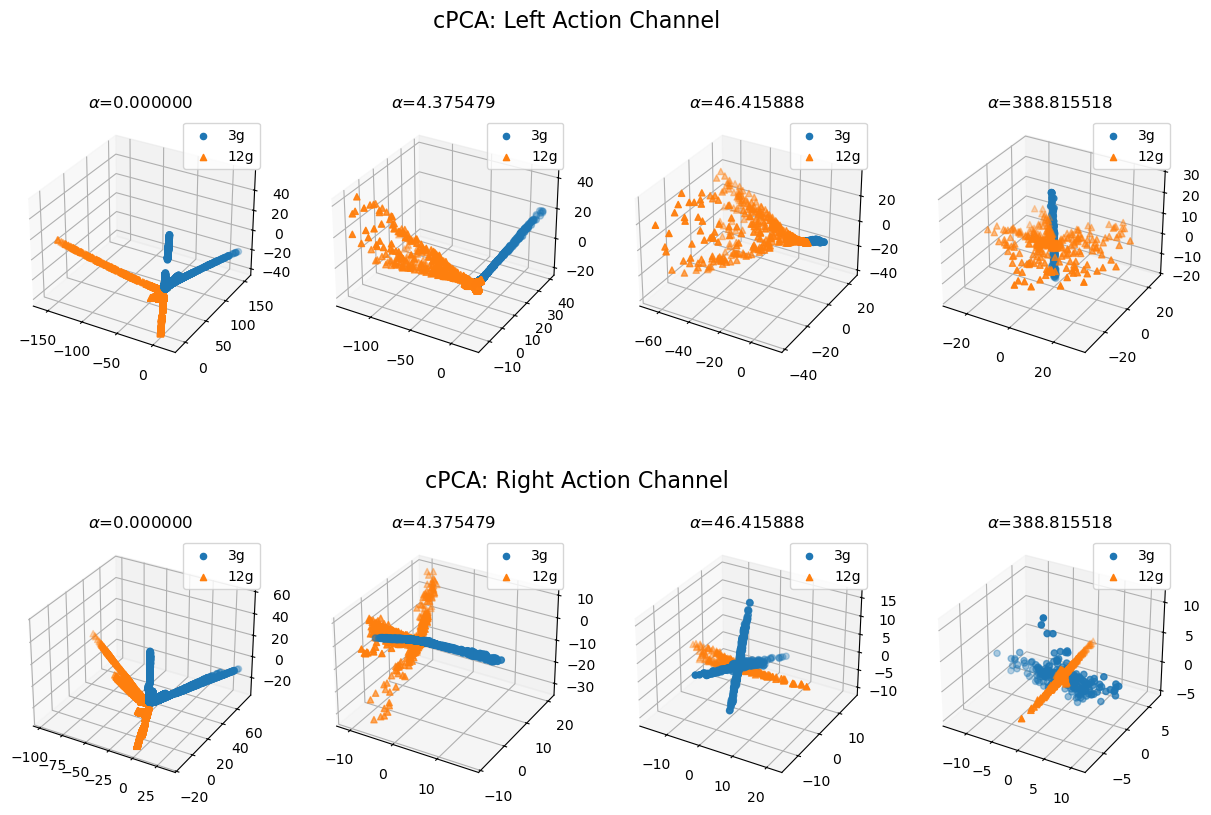

In [102]:
# LEFT GRAPHS
fig, axes = plt.subplots(2, len(alpha_left1), subplot_kw={'projection': '3d'}, figsize=(15, 10))
print(axes.shape)
def projected_data_3dplots(axes, data, alphas, labels, titles):
    for i in range(len(alphas)):
        # convert the data into real data 
        X = cpca_model.to_real(data[i])
        graph_labels = np.asarray(labels)
        f3 = graph_labels == 3
        f12 = graph_labels == 12
        # plot 
        axes[i].scatter(X[f3, 0],  X[f3, 1],  X[f3, 2],  label='3g',  marker='o')
        axes[i].scatter(X[f12, 0], X[f12, 1], X[f12, 2], label='12g', marker='^')
        axes[i].set_title(r'$\alpha$=' + f'{alpha_left[i]:2f}')
        axes[i].legend()


projected_data_3dplots(axes[0, :], left_cpca1, alpha_left1, left_label_fg1, titles=[])
projected_data_3dplots(axes[1, :], right_cpca1, alpha_right1, right_label_fg1, titles=[])

fig.text(0.5, 0.92, "cPCA: Left Action Channel", ha='center', fontsize=16)
fig.text(0.5, 0.46, "cPCA: Right Action Channel", ha='center', fontsize=16)
plt.show()